# EDA MathE

## Introduction

Tables Contained in this dataset:
- Assessment_Information
- Keyword_Information
- Keywords_by_Topic_Subtopic-1
- MathE_LLManswers
- MathE_public
- Questions_Information
- Teaching_Material_Information
- PDF_Keywords
- platform_materials-1
- DataGEMS & MathE Example of questions and answers 
- DataGEMS Chat examples

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

import warnings
warnings.filterwarnings("ignore")

In [2]:
assessment_information = pd.read_excel(r"datasets\assessment_information.xlsx")
keyword_information = pd.read_excel(r"datasets\keyword_information.xlsx")
keywords_by_topic_subtopic = pd.read_excel(r"keywords_by_topic_subtopic-1.xlsx")
mathE_LLManswer = pd.read_excel(r"datasets\MathE_LLManswers.xlsx")
mathE_public = pd.read_csv(r"datasets\MathE_public.csv", sep=";", encoding="cp1252")
questions_information = pd.read_excel(r"datasets\questions_information.xlsx")
teaching_material_information = pd.read_excel(r"datasets\teaching_material_information.xlsx")
pdf_keywords = pd.read_csv(r"datasets\pdf_keywords.csv", sep=";", encoding="cp1252")
platform_materials = pd.read_excel(r"platform_materials-1.xlsx")
datagems_example_q_a = pd.read_excel(r"datasets\DataGEMS & MathE Example of questions and answers.xlsx")
datagems_chat_example = pd.read_excel(r"datasets\DataGEMS Chat examples.xlsx") 

## Assessment_Information

In [3]:
assessment_information.head()

,student_id,question_id,answer,date,duration,option_selected,Topic,Subtopic,Lecturer_level,Algorithm_level,Typology
0,36,182,0,2019-04-18T08:11:32.000Z,NaN,NaN,Statistics,NaN,2,3,Student
1,36,81,0,2019-04-18T08:11:32.000Z,NaN,NaN,Statistics,NaN,1,3,Student
2,36,186,1,2019-04-18T08:11:32.000Z,NaN,NaN,Statistics,NaN,1,3,Student
3,36,181,0,2019-04-18T08:11:32.000Z,NaN,NaN,Statistics,NaN,1,3,Student
4,36,180,0,2019-04-18T08:11:32.000Z,NaN,NaN,Statistics,NaN,1,3,Student


In [4]:
assessment_information.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20241 entries, 0 to 20240
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   student_id       20241 non-null  int64  
 1   question_id      20241 non-null  int64  
 2   answer           20241 non-null  int64  
 3   date             20241 non-null  object 
 4   duration         30 non-null     float64
 5   option_selected  30 non-null     float64
 6   Topic            20241 non-null  object 
 7   Subtopic         13803 non-null  object 
 8   Lecturer_level   20241 non-null  int64  
 9   Algorithm_level  20241 non-null  int64  
 10  Typology         20241 non-null  object 
dtypes: float64(2), int64(5), object(4)
memory usage: 1.7+ MB


All columns are completed, except for:
- "duration" (30 / 20.241)
- "option_selected" (30 / 20.241)
- "Subtopic" (13.803 / 20.241)

In [5]:
assessment_information['date'] = pd.to_datetime(assessment_information['date'], errors='coerce')
assessment_information.describe()

,student_id,question_id,answer,duration,option_selected,Lecturer_level,Algorithm_level
count,20241.000000,20241.000000,20241.000000,30.000000,30.000000,20241.000000,20241.000000
mean,1823.882812,611.887950,0.310953,97.466667,1.300000,2.648832,2.488563
std,1092.286153,386.032513,0.698773,197.304899,1.417866,1.353007,1.325815
min,36.000000,79.000000,-1.000000,2.000000,0.000000,0.000000,1.000000
25%,966.000000,328.000000,0.000000,16.500000,0.000000,1.000000,1.000000
50%,1694.000000,514.000000,0.000000,42.000000,1.000000,3.000000,2.000000
75%,2954.000000,823.000000,1.000000,78.750000,2.000000,4.000000,4.000000
max,3538.000000,2180.000000,1.000000,1063.000000,4.000000,5.000000,6.000000


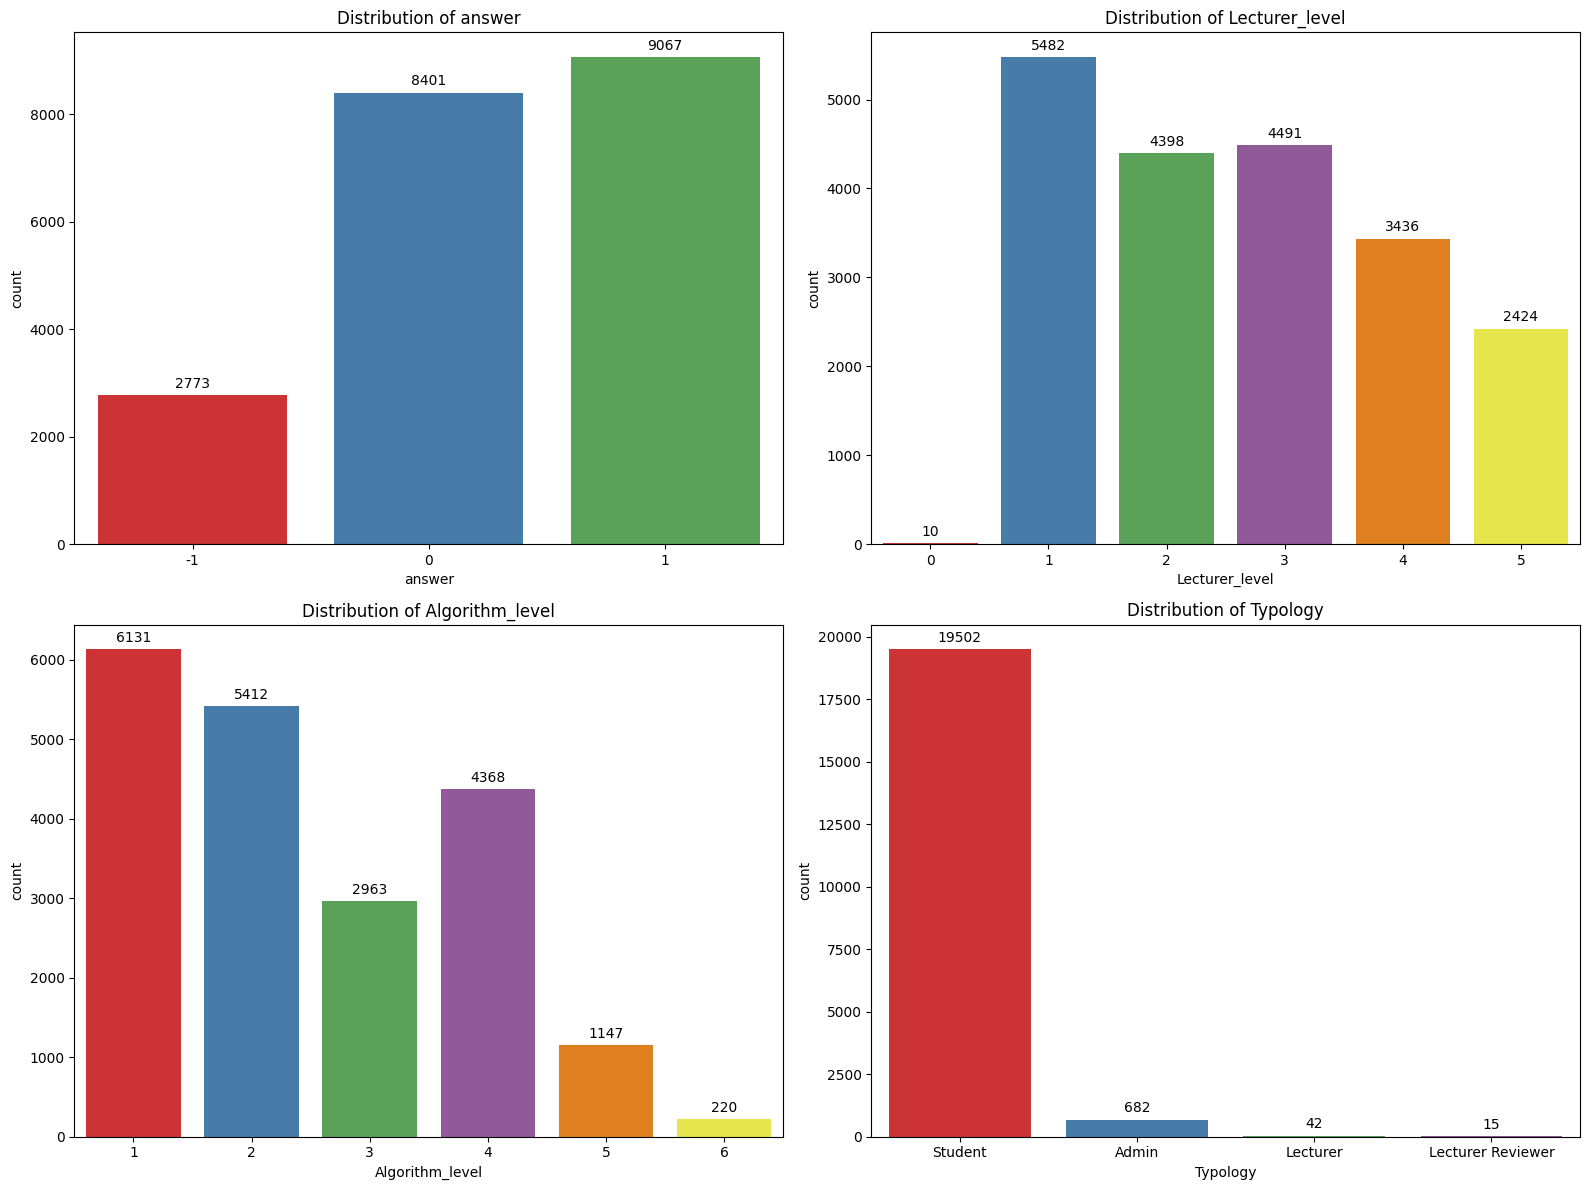

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

columns = ['answer', 'Lecturer_level', 'Algorithm_level', 'Typology']
coords = [(0, 0), (0, 1), (1, 0), (1, 1)]

for col, coord in zip(columns, coords):
    ax = axes[coord[0], coord[1]]
    sns.countplot(x=col, data=assessment_information, ax=ax, palette='Set1')
    ax.set_title(f'Distribution of {col}')
    
    for container in ax.containers:
        ax.bar_label(container, padding=3)

plt.tight_layout()
plt.show()

Answer: 
*  1 = corretta 
*  0 = sbagliata 
* -1 = non so

Algorithm_Level = difficolta domanda

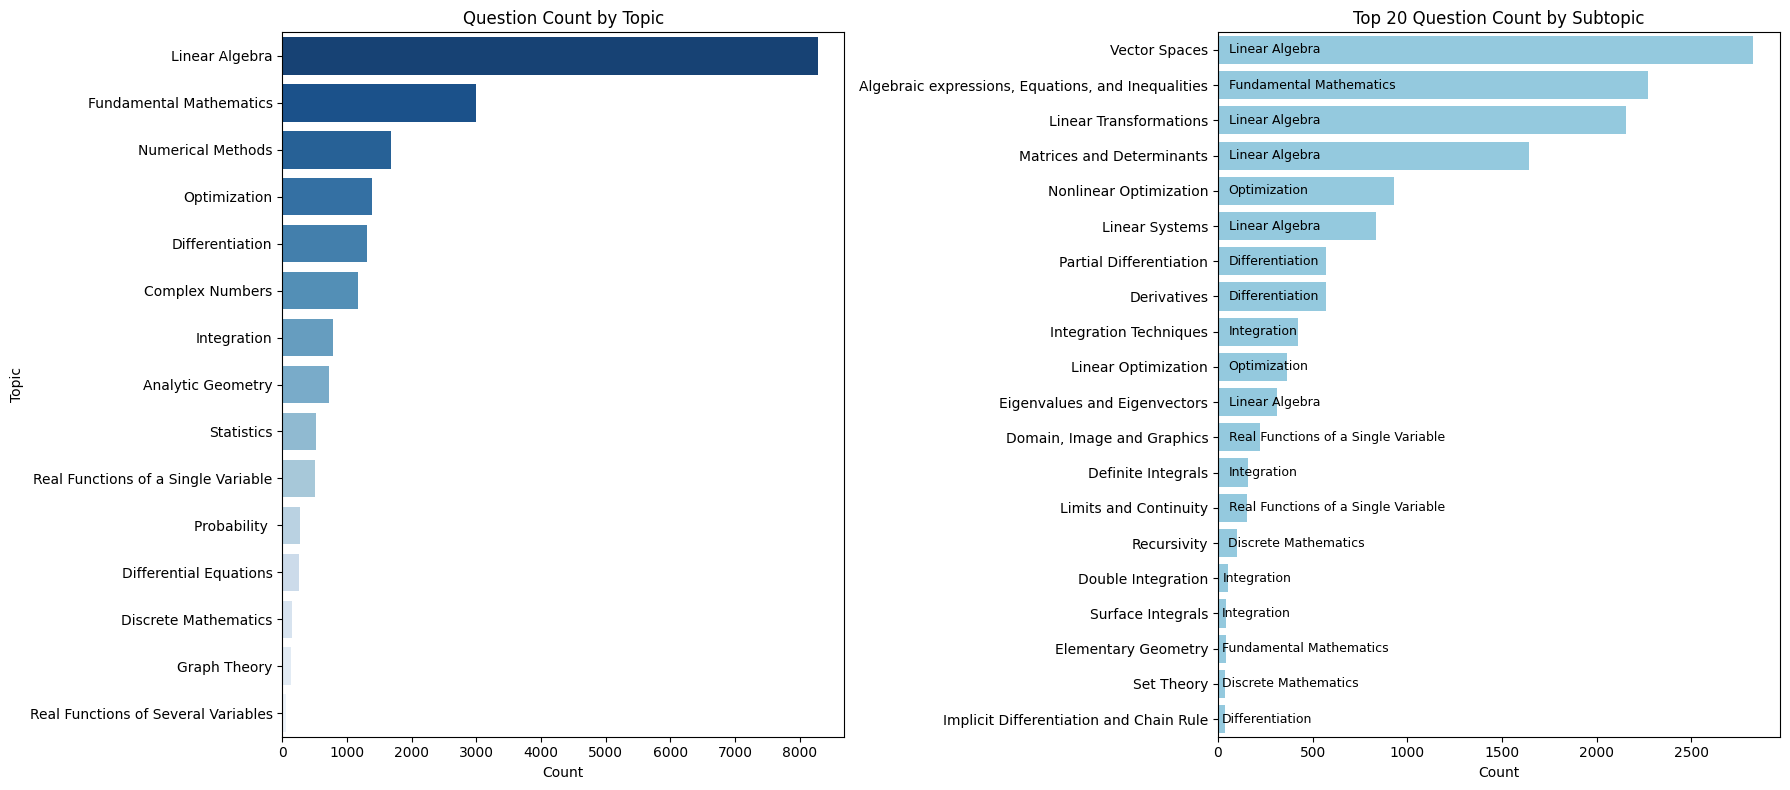

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Topic subplot
topic_counts = assessment_information["Topic"].value_counts()
sns.barplot(
    x=topic_counts.values,
    y=topic_counts.index,
    ax=axes[0],
    palette="Blues_r"
)
axes[0].set_title("Question Count by Topic")
axes[0].set_xlabel("Count")

# Topic + Subtopic subplot (top 20 to keep it readable)
topic_subtopic_counts = (
    assessment_information.dropna(subset=["Subtopic"])
.groupby(["Topic", "Subtopic"])
.size()
.sort_values(ascending=False)
.head(20)
)

topics = [topic for topic, _ in topic_subtopic_counts.index]
subtopics = [subtopic for _, subtopic in topic_subtopic_counts.index]
counts = topic_subtopic_counts.values

sns.barplot(
    x=counts,
    y=subtopics,
    ax=axes[1],
    color='skyblue'
)

# Add topic labels inside each bar
x_offset = counts.max() * 0.02
for i, (count, topic) in enumerate(zip(counts, topics)):
    x_text = min(x_offset, count * 0.5)
    axes[1].text(
        x_text,
        i,
        topic,
        va="center",
        ha="left",
        color="black",
        fontsize=9,
    )

axes[1].set_title("Top 20 Question Count by Subtopic")
axes[1].set_xlabel("Count")

plt.tight_layout()
plt.show()

## Keyword_Information

In [8]:
display(keyword_information.head())
print('\n' + str(keyword_information.shape[0]) + ' rows and ' + str(keyword_information.shape[1]) + ' columns')
print(keyword_information['keyword'].nunique(), 'unique keywords')

,id,keyword,Associated_Questions,Topic,Subtopic,countTeachingMaterials,countVideos
0,1,Trigonometric functions,2,Fundamental Mathematics,"Algebraic expressions, Equations, and Inequali...",0,2
1,2,Exponential function,9,Fundamental Mathematics,"Algebraic expressions, Equations, and Inequali...",2,2
2,3,Linear equations,13,Fundamental Mathematics,"Algebraic expressions, Equations, and Inequali...",3,2
3,4,Quadratic equations,21,Fundamental Mathematics,"Algebraic expressions, Equations, and Inequali...",4,3
4,5,Simplify expressions,71,Fundamental Mathematics,"Algebraic expressions, Equations, and Inequali...",13,18



399 rows and 7 columns
376 unique keywords


In [9]:
keyword_information.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 399 entries, 0 to 398
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   id                      399 non-null    int64 
 1   keyword                 399 non-null    object
 2   Associated_Questions    399 non-null    int64 
 3   Topic                   399 non-null    object
 4   Subtopic                253 non-null    object
 5   countTeachingMaterials  399 non-null    int64 
 6   countVideos             399 non-null    int64 
dtypes: int64(4), object(3)
memory usage: 21.9+ KB


In [10]:
keyword_information.describe()

,id,Associated_Questions,countTeachingMaterials,countVideos
count,399.000000,399.000000,399.000000,399.000000
mean,218.428571,12.060150,2.486216,2.433584
std,130.353267,12.903445,5.715551,2.782749
min,1.000000,0.000000,0.000000,0.000000
25%,104.500000,3.000000,0.000000,1.000000
50%,213.000000,7.000000,1.000000,2.000000
75%,333.500000,18.000000,2.000000,3.000000
max,441.000000,83.000000,72.000000,18.000000


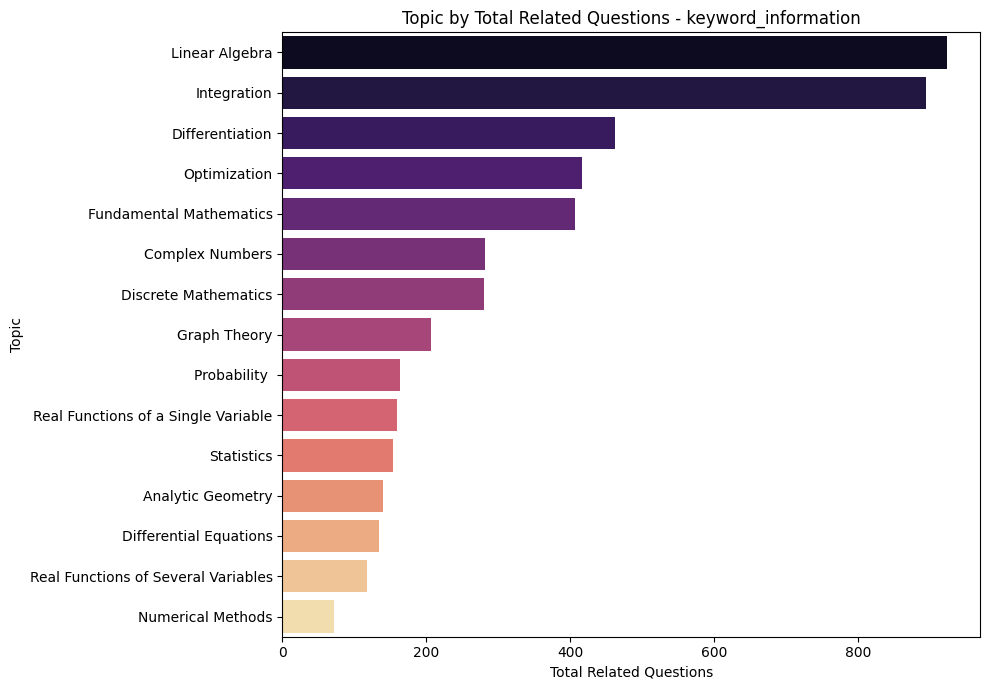

In [11]:
# Topic plot in keyword_information using total related questions

plt.figure(figsize=(10, 7))

topic_totals = (
        keyword_information
        .groupby(keyword_information['Topic'])['Associated_Questions']
        .sum()
        .sort_values(ascending=False)
    )
sns.barplot(
        x=topic_totals.values,
        y=topic_totals.index,
        palette="magma"
    )
plt.title("Topic by Total Related Questions - keyword_information")
plt.xlabel("Total Related Questions")
plt.ylabel("Topic")

plt.tight_layout()
plt.show()

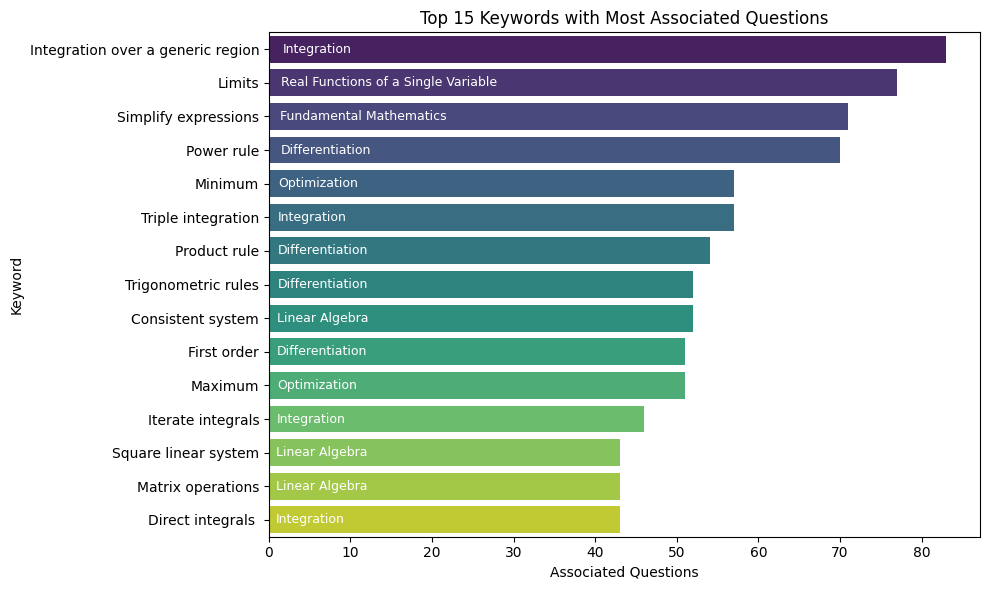

In [12]:
# Top keywords by Associated_Questions
top_keywords = (
    keyword_information.groupby("keyword", as_index=False)["Associated_Questions"]
    .sum()
    .sort_values("Associated_Questions", ascending=False)
    .head(15)
)

# Attach topic information if a topic-like column is available in keyword_information
topic_col = next(
    (col for col in keyword_information.columns if "topic" in col.lower()),
    None,
 )

if topic_col is not None:
    keyword_topic = (
        keyword_information[["keyword", topic_col]]
        .dropna(subset=[topic_col])
        .drop_duplicates(subset=["keyword"])
)
    top_keywords = top_keywords.merge(keyword_topic, on="keyword", how="left")
else:
    top_keywords["_topic_label"] = "N/A"
    topic_col = "_topic_label"

plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=top_keywords,
    x="Associated_Questions",
    y="keyword",
    palette="viridis"
)

ax.set_title("Top 15 Keywords with Most Associated Questions")
ax.set_xlabel("Associated Questions")
ax.set_ylabel("Keyword")

# Put topic labels inside each horizontal bar
for i, (_, row) in enumerate(top_keywords.iterrows()):
    x_value = row["Associated_Questions"]
    topic_text = str(row[topic_col]) if pd.notna(row[topic_col]) else "N/A"
    x_text = max(0.2, x_value * 0.02)
    ax.text(x_text, i, topic_text, va="center", ha="left", color="white", fontsize=9)

plt.tight_layout()
plt.show()

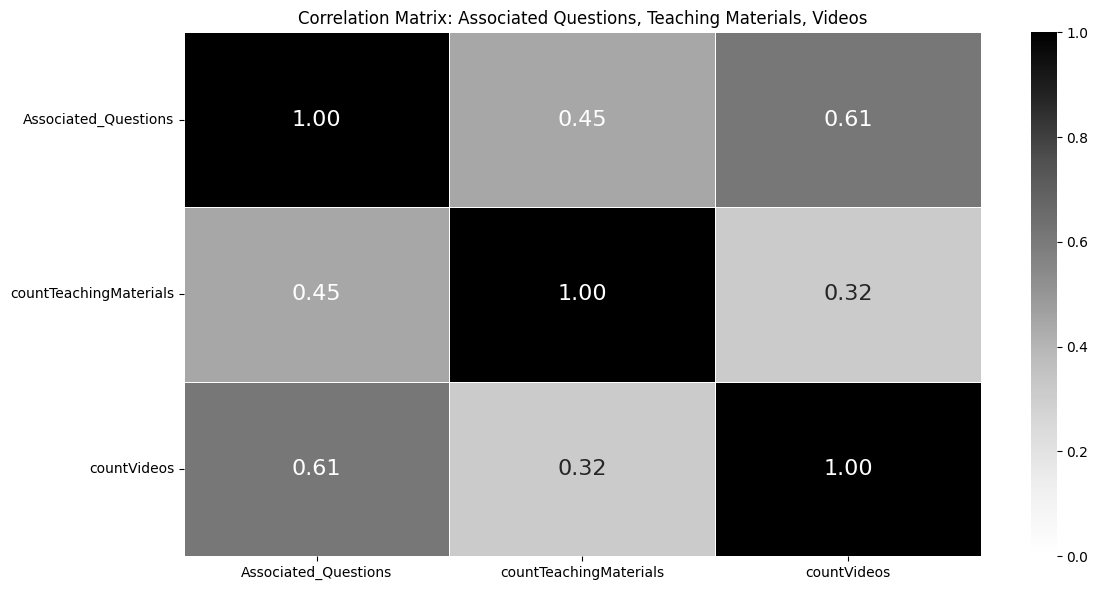

In [13]:
corr = keyword_information[[ 'Associated_Questions', 'countTeachingMaterials', 'countVideos' ]].corr()

plt.figure(figsize=(12, 6))
sns.heatmap(
    corr,
    annot=True,
    annot_kws={"size": 16},
    cmap="Greys",
    fmt=".2f",
    linewidths=0.5,
    vmin=-0,
    vmax=1
)
plt.title("Correlation Matrix: Associated Questions, Teaching Materials, Videos")

plt.tight_layout()
plt.show()

## keywords_by_topic_subtopic

In [14]:
keywords_by_topic_subtopic.head()

,Topic,Subtopic,Keywords
0,Analytic Geometry,NaN,Bases
1,Analytic Geometry,NaN,Cartesian equations of a line
2,Analytic Geometry,NaN,Cartesian equations of a plane
3,Analytic Geometry,NaN,Collinearity
4,Analytic Geometry,NaN,Cross product


In [15]:
keywords_by_topic_subtopic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 399 entries, 0 to 398
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Topic     399 non-null    object
 1   Subtopic  262 non-null    object
 2   Keywords  399 non-null    object
dtypes: object(3)
memory usage: 9.5+ KB


In [16]:
keywords_by_topic_subtopic.describe()

,Topic,Subtopic,Keywords
count,399,262,399
unique,14,22,376
top,Linear Algebra,Set Theory,Trigonometric functions
freq,63,19,3


## MathE_LLManswers

In [17]:
mathE_LLManswer.drop(columns=['Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13'], inplace=True)
mathE_LLManswer.head()

,id,question,Manu_Correct_Answer,DeepSeek_Correct_Answer,Topic,Subtopic,LecturerLevel,algorithmLevel,Manus_Right,DeepSeek_Right
0,79,What number is missing from the table?\n\n$\be...,2,1,Statistics,NaN,1,3,0,1
1,80,The amount spent on entertainment in a month w...,3,1,Statistics,NaN,1,3,0,1
2,81,The amount spent on entertainment in a month w...,1,1,Statistics,NaN,1,3,1,1
3,82,Differentiate $\displaystyle{y = 2x\sin(x)}$.,1,1,Differentiation,Derivatives,1,1,1,1
4,83,The image of the function $f(x)=x^3+\log (x)$ is,3,1,Real Functions of a Single Variable,"Domain, Image and Graphics",2,1,0,1


In [18]:
mathE_LLManswer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1913 entries, 0 to 1912
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   id                       1913 non-null   int64 
 1   question                 1913 non-null   object
 2   Manu_Correct_Answer      1913 non-null   int64 
 3   DeepSeek_Correct_Answer  1913 non-null   int64 
 4   Topic                    1913 non-null   object
 5   Subtopic                 1447 non-null   object
 6   LecturerLevel            1913 non-null   int64 
 7   algorithmLevel           1913 non-null   int64 
 8   Manus_Right              1913 non-null   int64 
 9   DeepSeek_Right           1913 non-null   int64 
dtypes: int64(7), object(3)
memory usage: 149.6+ KB


In [19]:
mathE_LLManswer.describe()

,id,Manu_Correct_Answer,DeepSeek_Correct_Answer,LecturerLevel,algorithmLevel,Manus_Right,DeepSeek_Right
count,1913.000000,1913.000000,1913.000000,1913.000000,1913.000000,1913.000000,1913.000000
mean,1127.670152,2.539467,1.051228,2.940408,2.682175,0.217459,0.973863
std,619.963420,1.085582,0.335316,1.341564,1.358524,0.412626,0.159584
min,79.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000
25%,580.000000,2.000000,1.000000,2.000000,2.000000,0.000000,1.000000
50%,1099.000000,3.000000,1.000000,3.000000,3.000000,0.000000,1.000000
75%,1679.000000,3.000000,1.000000,4.000000,4.000000,0.000000,1.000000
max,2187.000000,4.000000,4.000000,5.000000,6.000000,1.000000,1.000000


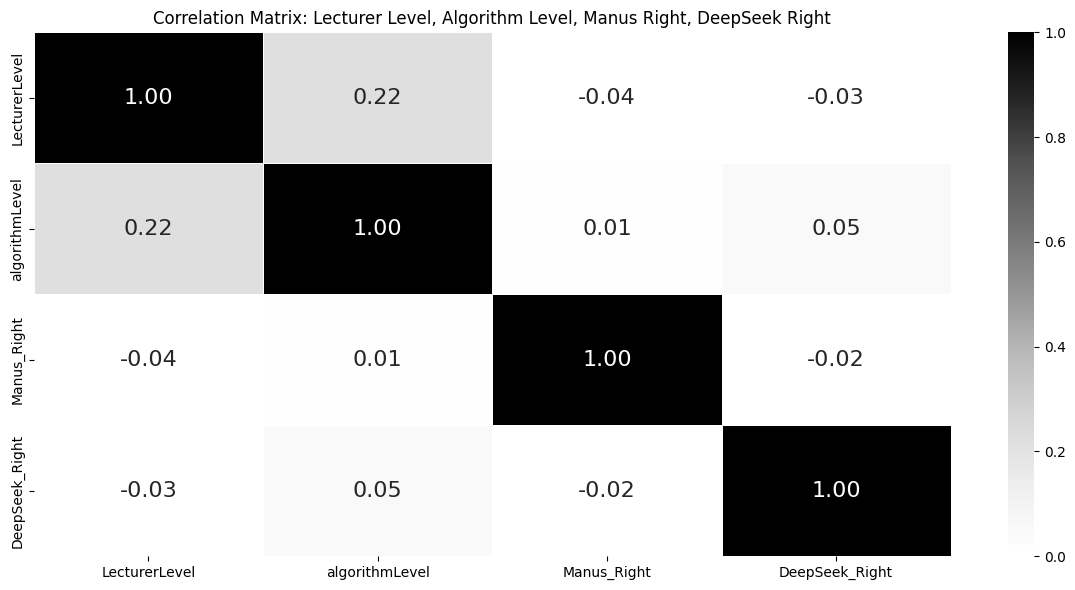

In [20]:


corr = mathE_LLManswer[[ 'LecturerLevel', 'algorithmLevel', 'Manus_Right', 'DeepSeek_Right' ]].corr()

plt.figure(figsize=(12, 6))
sns.heatmap(
    corr,
    annot=True,
    annot_kws={"size": 16},
    cmap="Greys",
    fmt=".2f",
    linewidths=0.5,
    vmin=-0,
    vmax=1
)
plt.title("Correlation Matrix: Lecturer Level, Algorithm Level, Manus Right, DeepSeek Right")

plt.tight_layout()
plt.show()

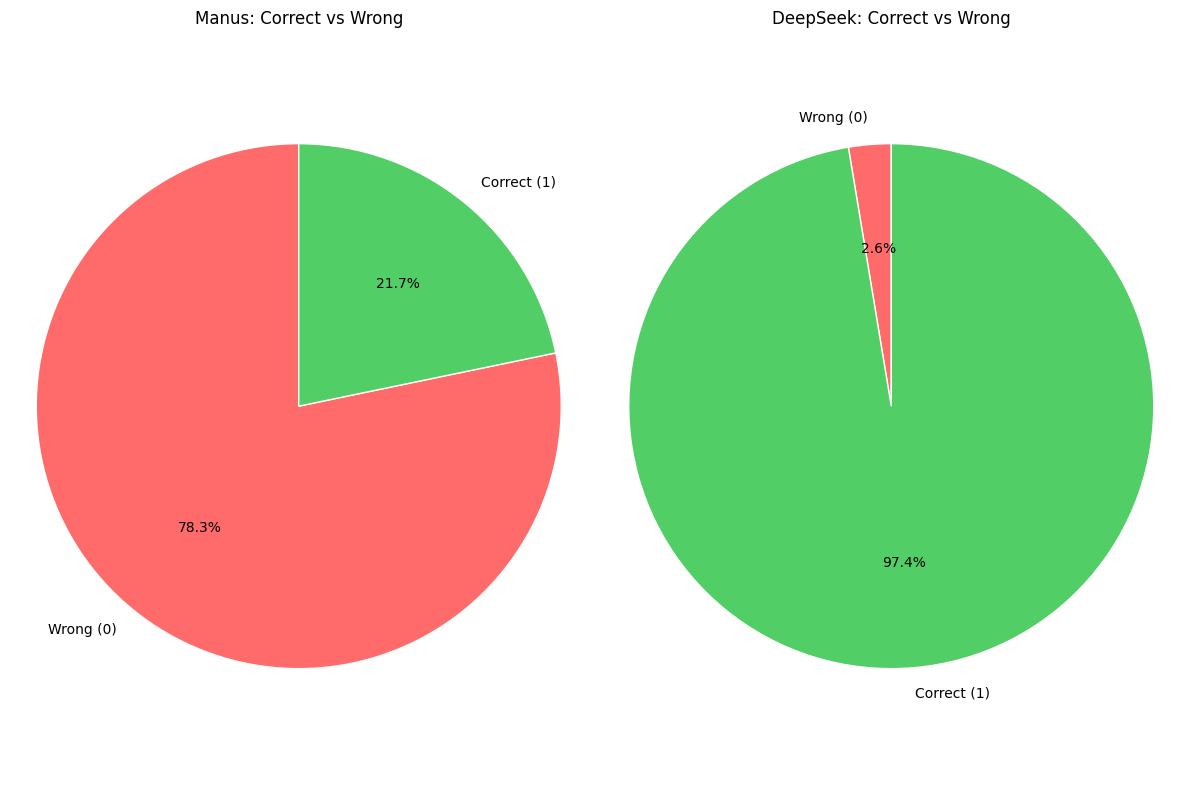

In [21]:
labels = ["Wrong (0)", "Correct (1)"]
manus_counts = mathE_LLManswer["Manus_Right"].value_counts().reindex([0, 1], fill_value=0)
deepseek_counts = mathE_LLManswer["DeepSeek_Right"].value_counts().reindex([0, 1], fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(12, 8))

for ax, counts, title in zip(
    axes,
    [manus_counts, deepseek_counts],
    ["Manus: Correct vs Wrong", "DeepSeek: Correct vs Wrong"]
):
    ax.pie(
        counts.values,
        labels=labels,
        autopct="%1.1f%%",
        startangle=90,
        colors=["#ff6b6b", "#51cf66"],
        wedgeprops={"edgecolor": "white"}
    )
    ax.set_title(title)
    ax.axis("equal")

plt.tight_layout()
plt.show()

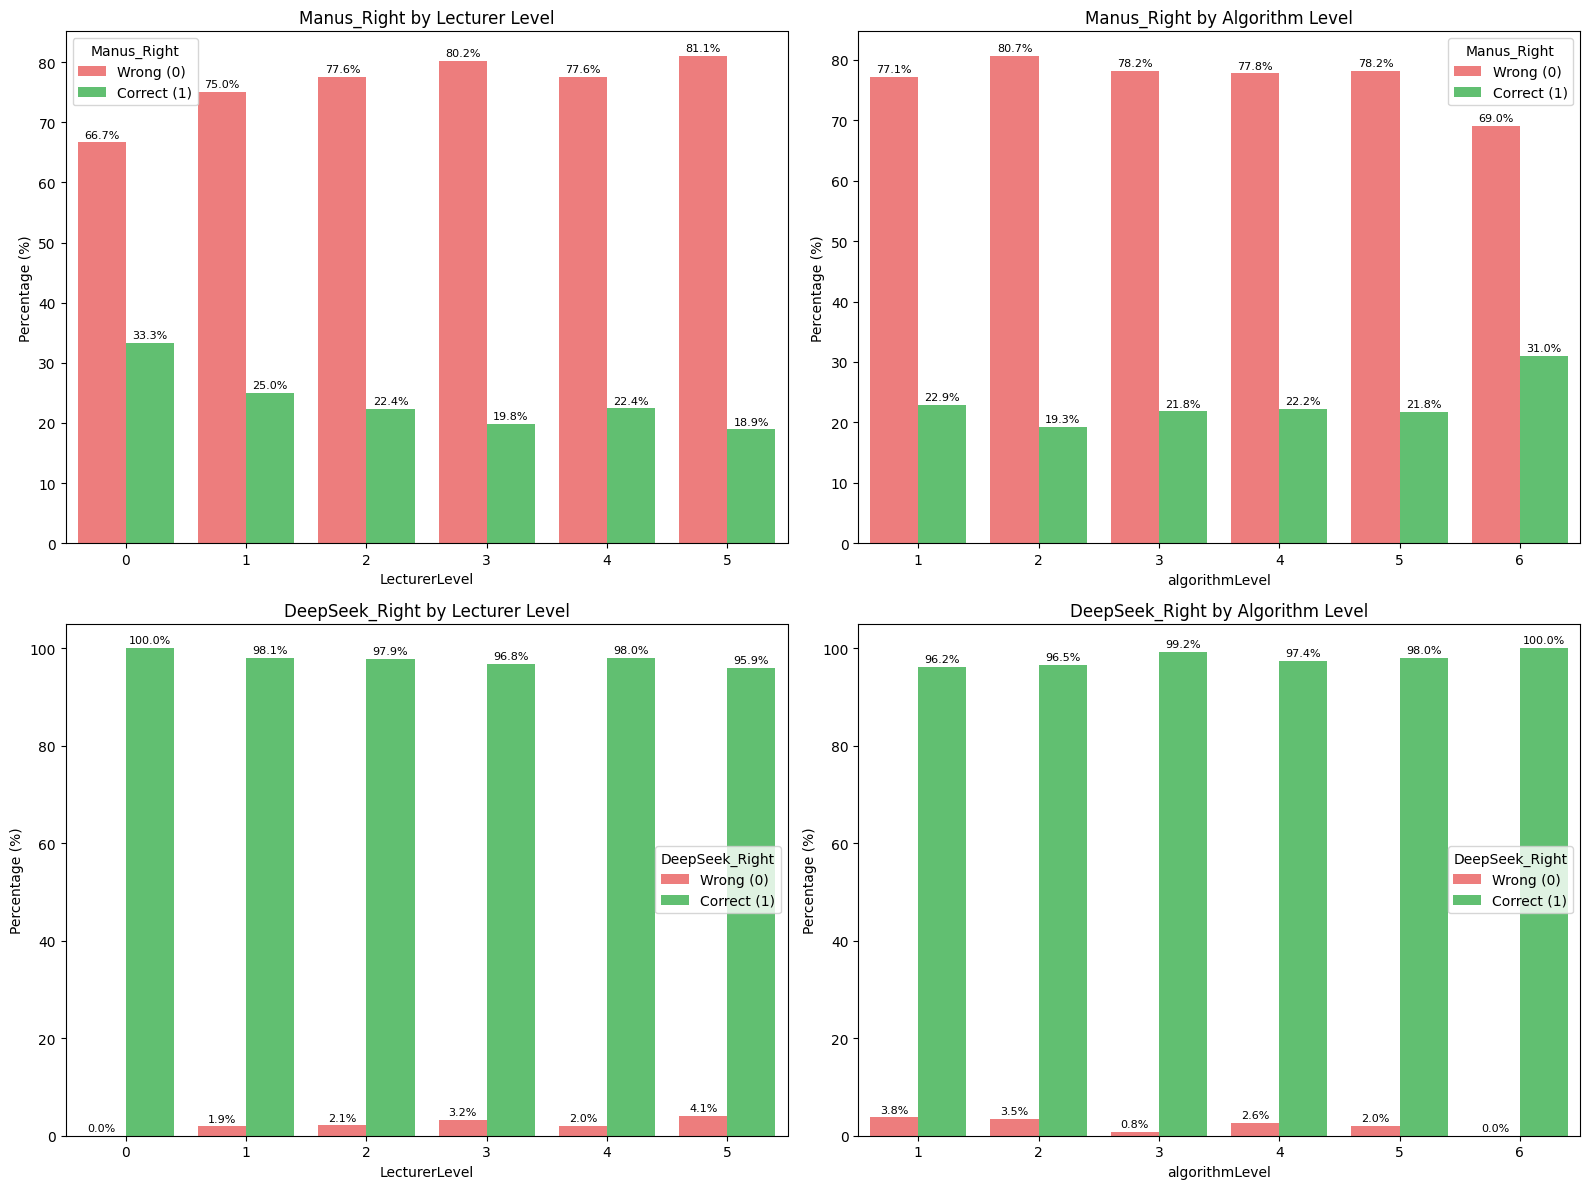

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

plots = [
    ("LecturerLevel", "Manus_Right", "Manus_Right by Lecturer Level"),
    ("algorithmLevel", "Manus_Right", "Manus_Right by Algorithm Level"),
    ("LecturerLevel", "DeepSeek_Right", "DeepSeek_Right by Lecturer Level"),
    ("algorithmLevel", "DeepSeek_Right", "DeepSeek_Right by Algorithm Level"),
]

for ax, (x_col, hue_col, title) in zip(axes.flatten(), plots):
    pct_df = (
        pd.crosstab(mathE_LLManswer[x_col], mathE_LLManswer[hue_col], normalize="index")
        .mul(100)
        .reindex(columns=[0, 1], fill_value=0)
        .reset_index()
        .melt(id_vars=x_col, var_name=hue_col, value_name="pct")
    )

    sns.barplot(
        data=pct_df,
        x=x_col,
        y="pct",
        hue=hue_col,
        hue_order=[0, 1],
        palette={0: "#ff6b6b", 1: "#51cf66"},
        ax=ax
    )
    ax.set_title(title)
    ax.set_xlabel(x_col)
    ax.set_ylabel("Percentage (%)")

    handles, legend_labels = ax.get_legend_handles_labels()
    legend_map = {"0": "Wrong (0)", "1": "Correct (1)", 0: "Wrong (0)", 1: "Correct (1)"}
    mapped_labels = [legend_map.get(lbl, str(lbl)) for lbl in legend_labels]
    ax.legend(handles, mapped_labels, title=hue_col)

    for container in ax.containers:
        labels = [f"{bar.get_height():.1f}%" for bar in container]
        ax.bar_label(container, labels=labels, padding=2, fontsize=8)

plt.tight_layout()
plt.show()

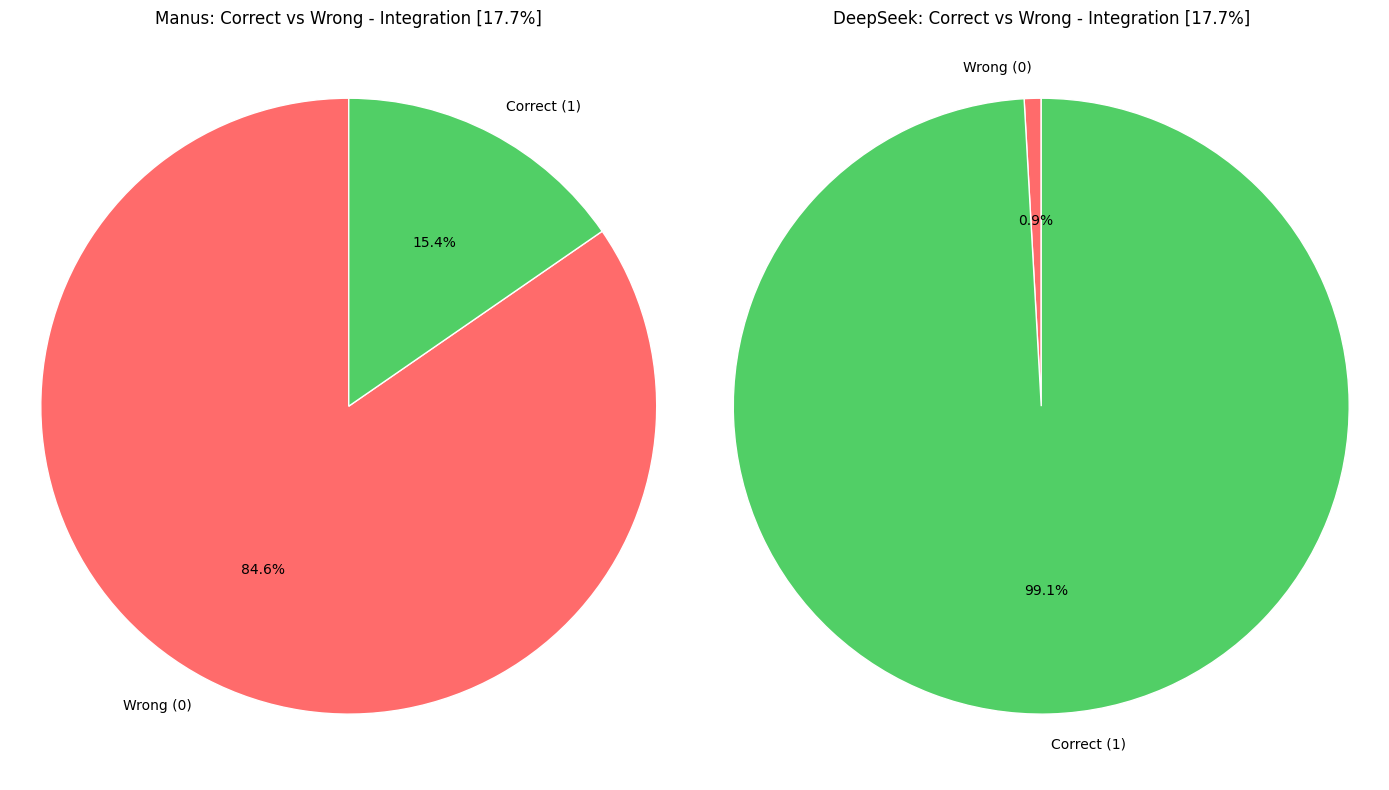

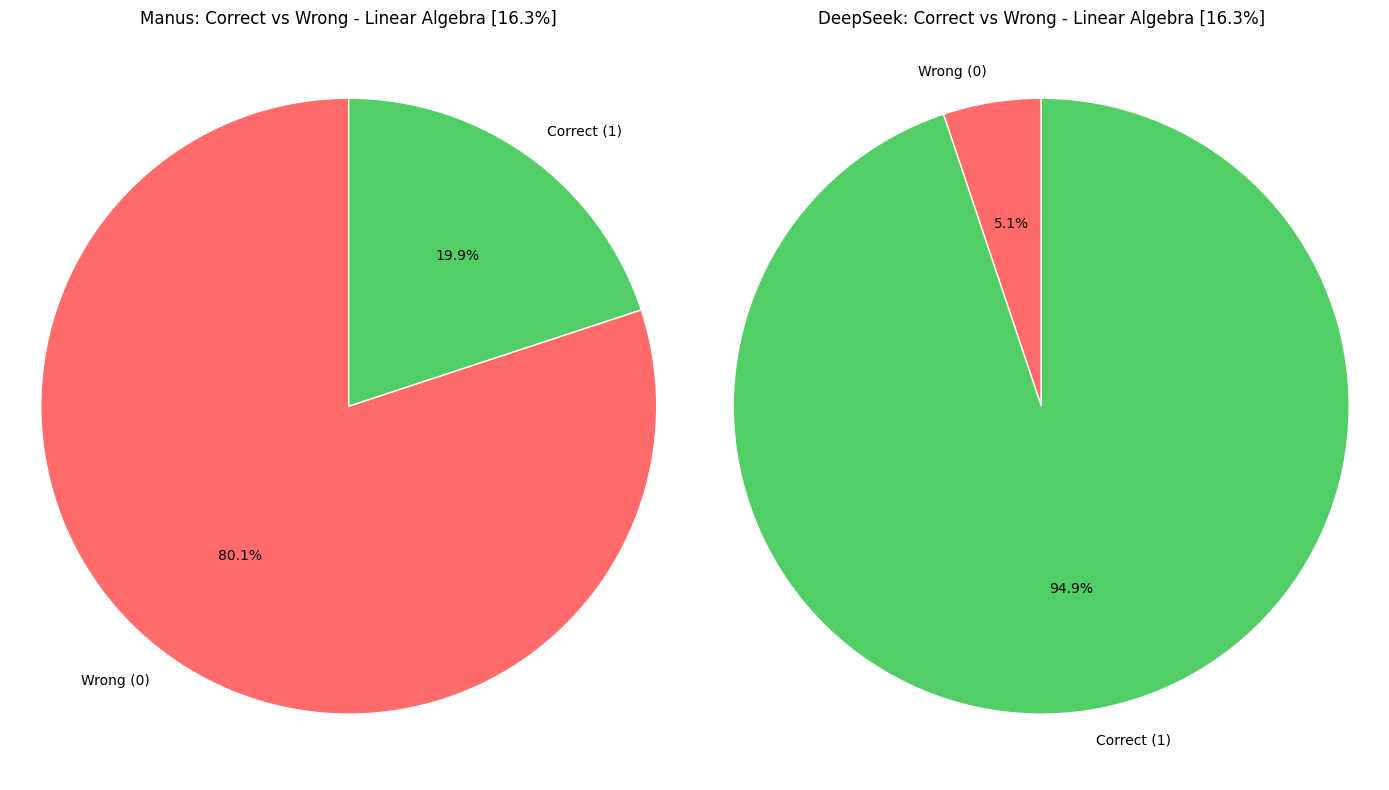

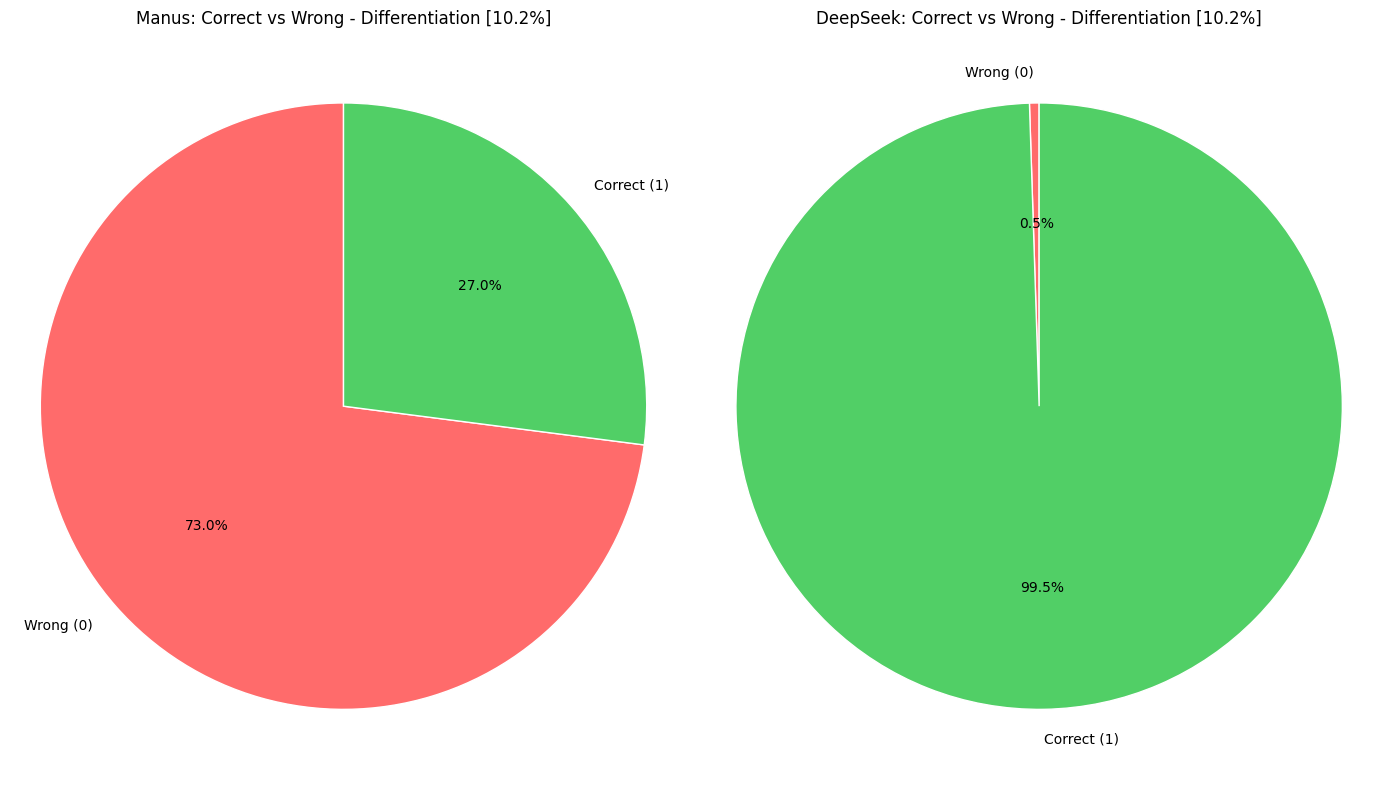

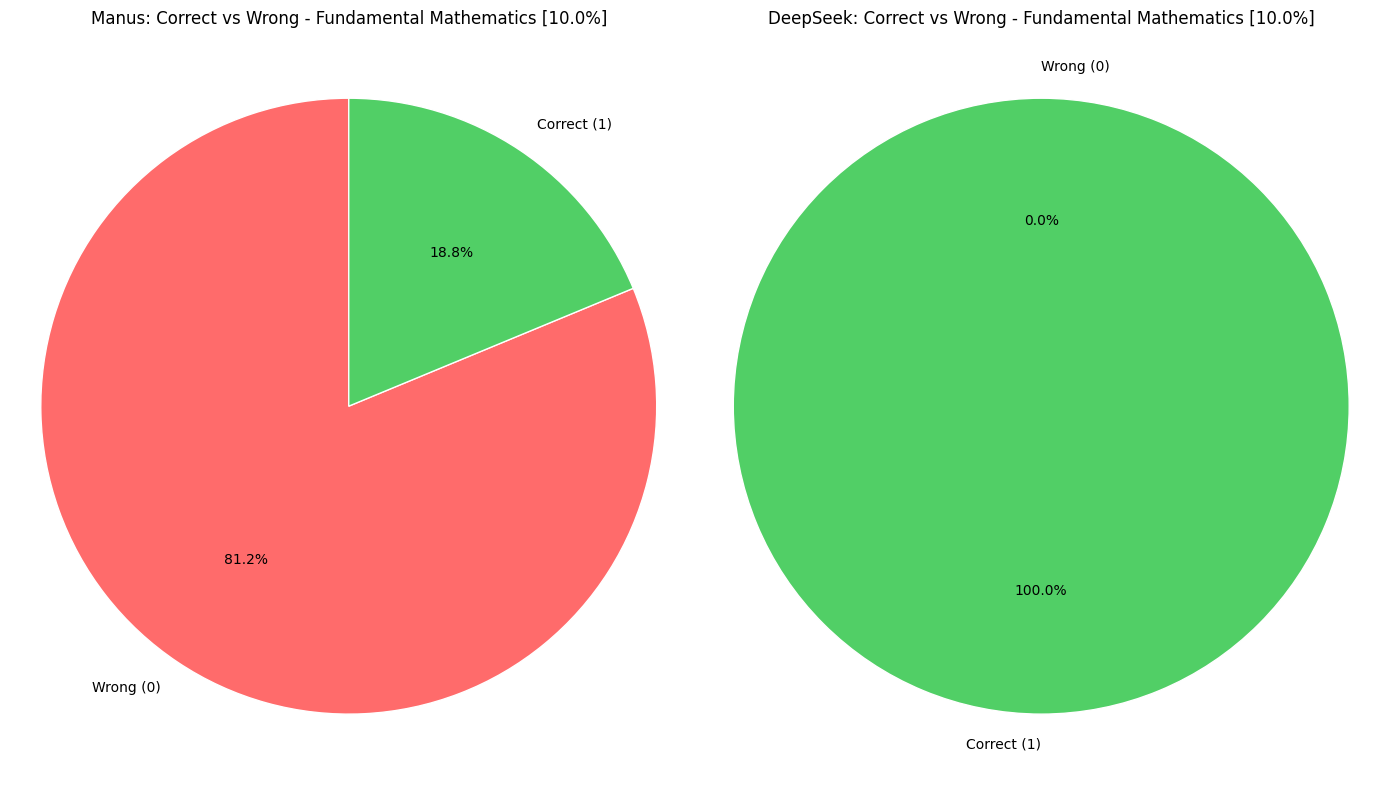

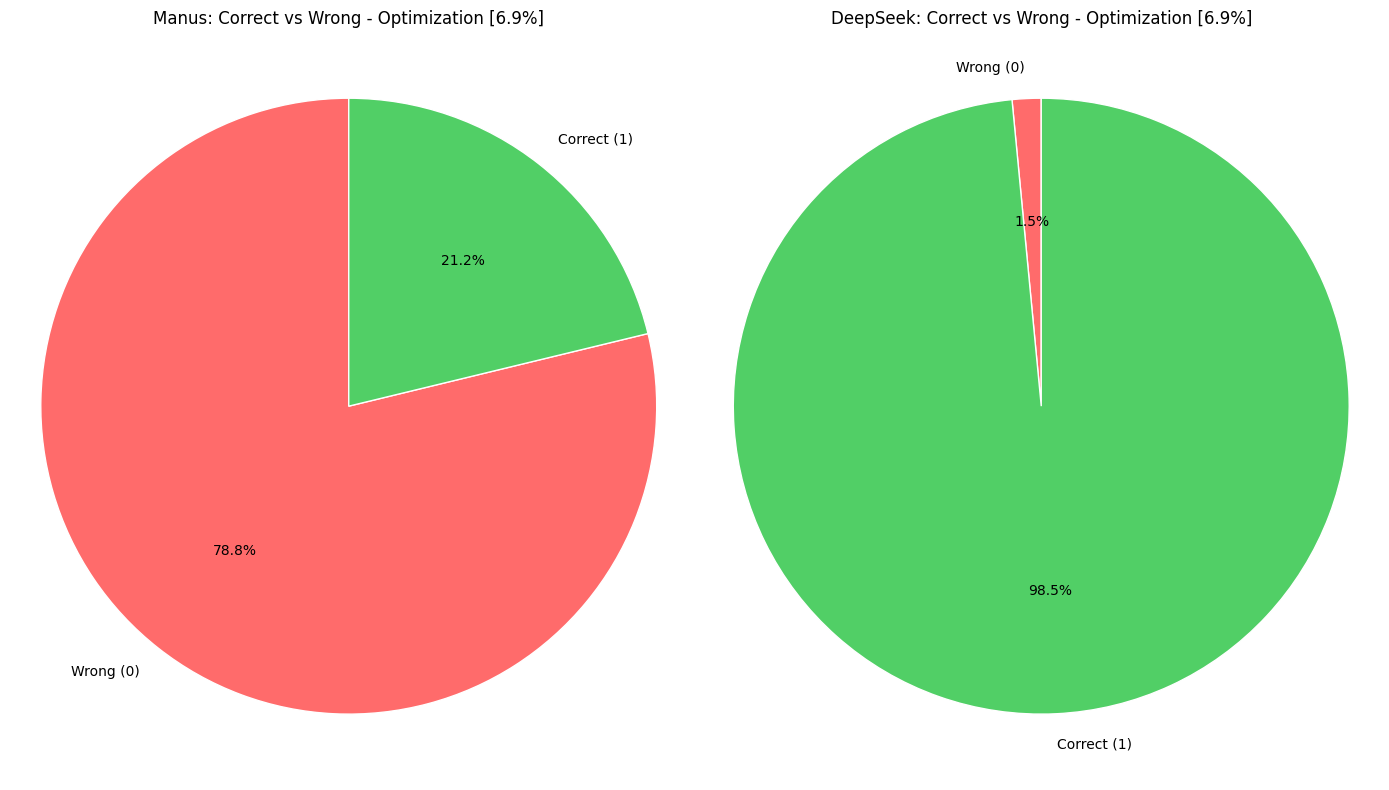

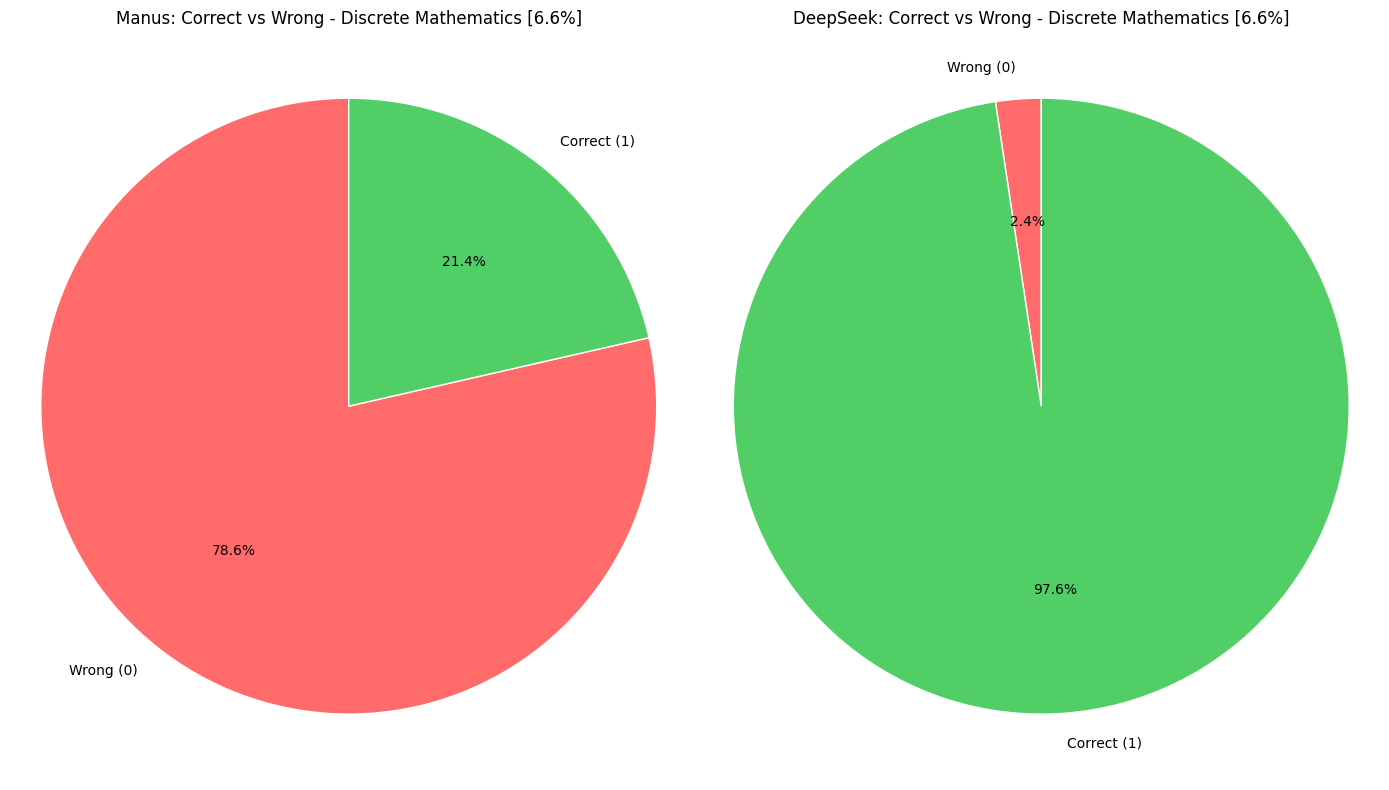

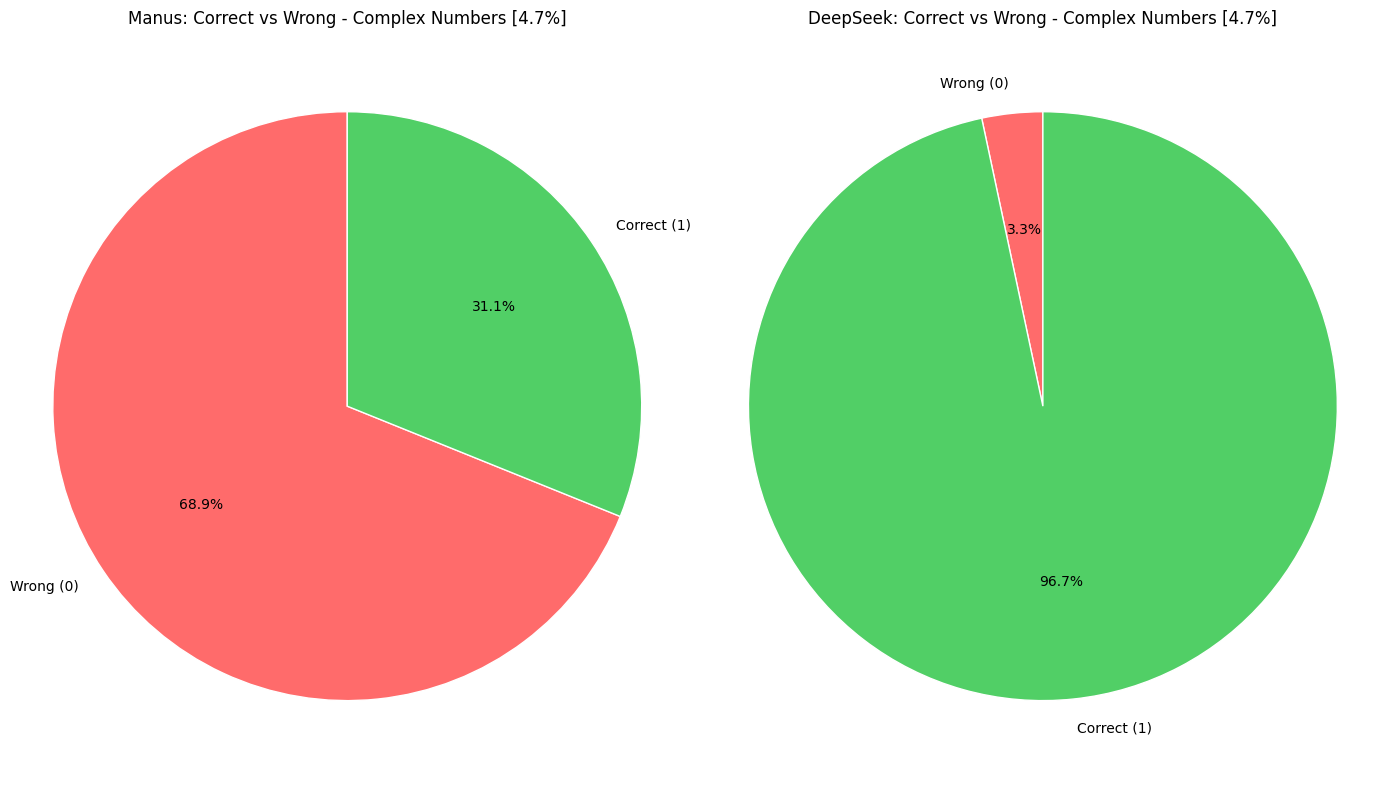

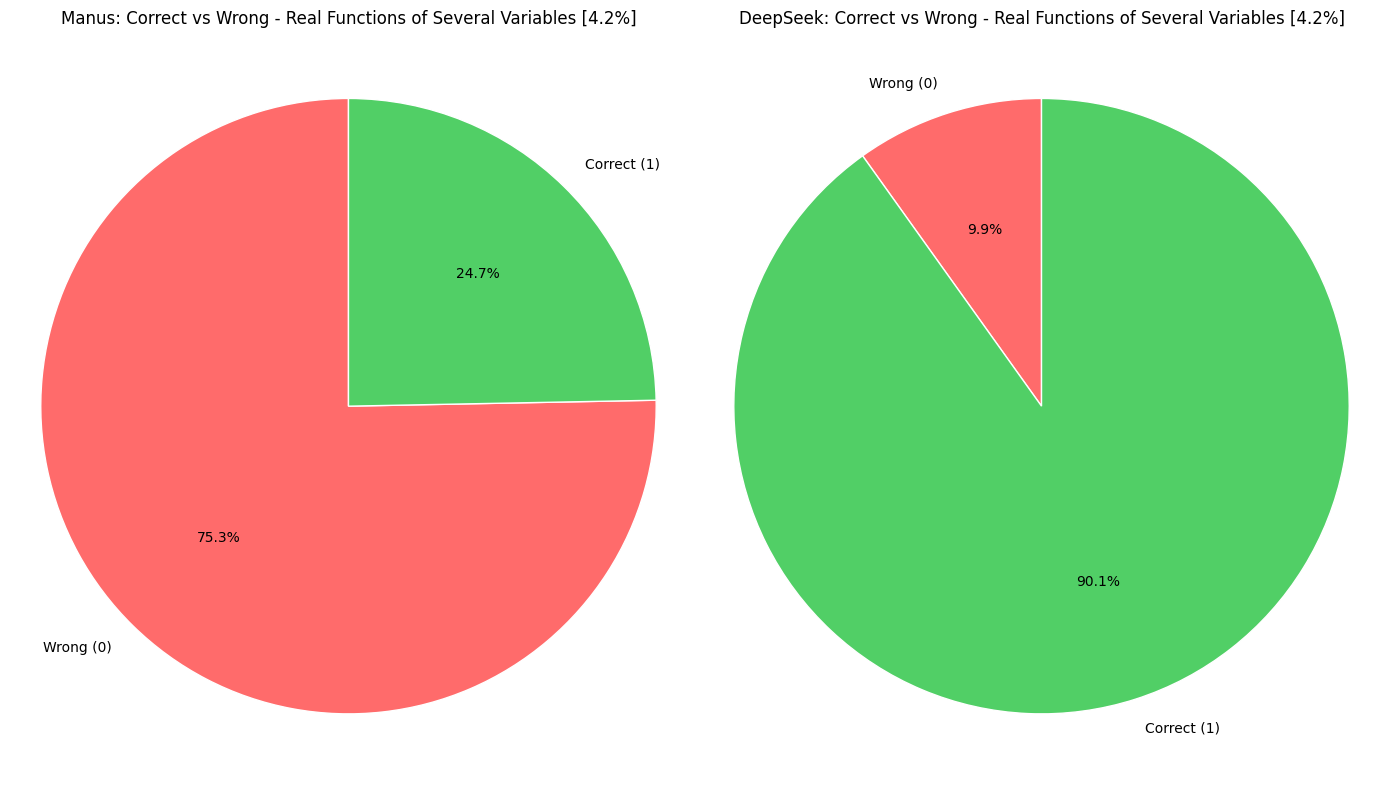

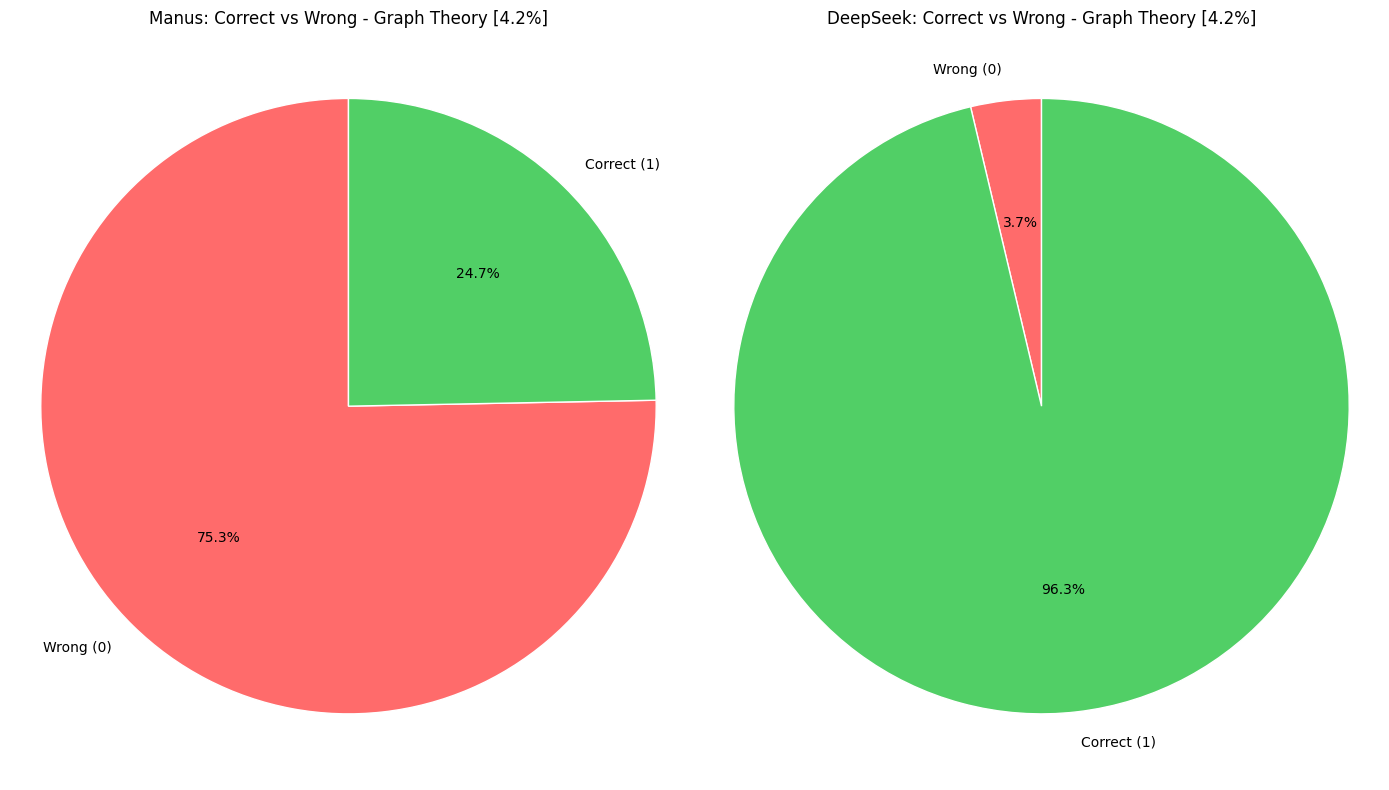

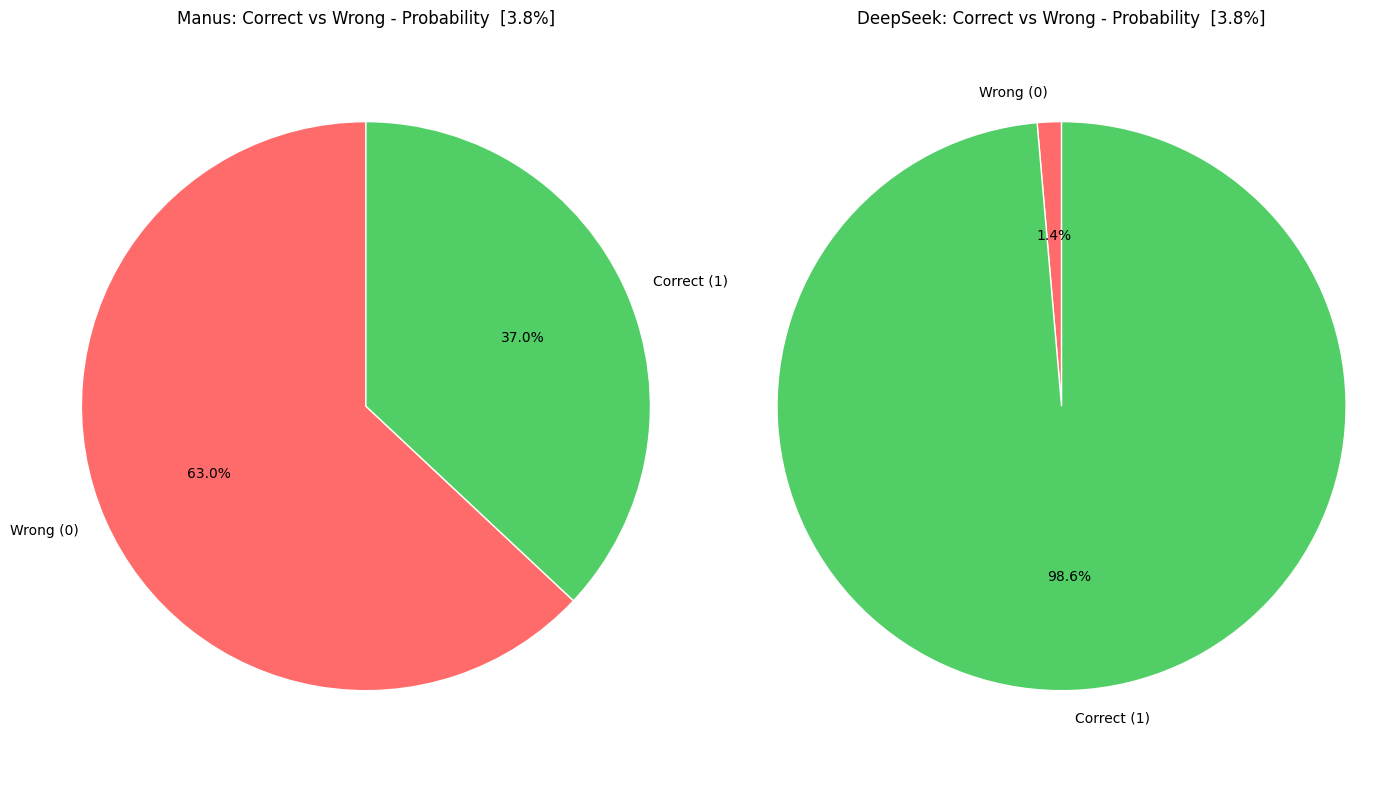

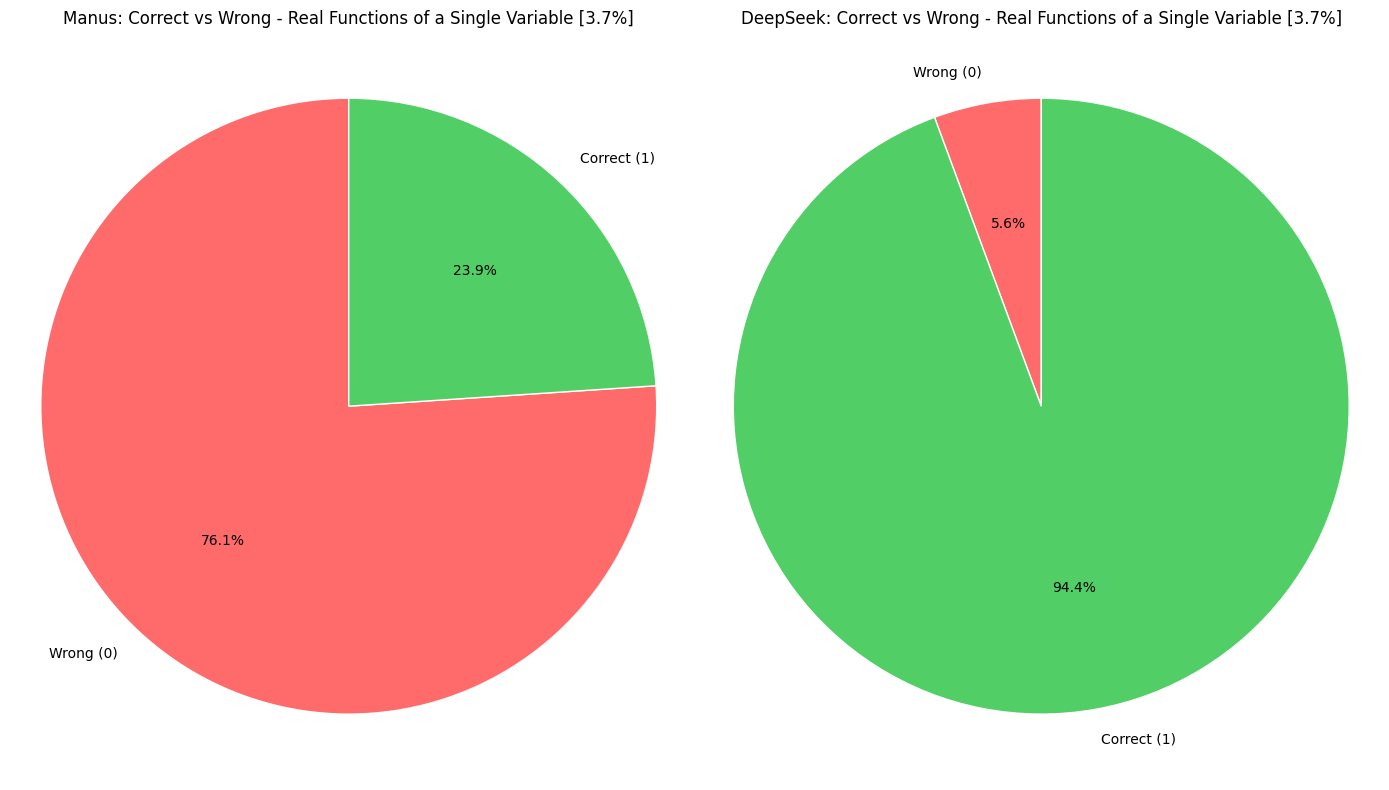

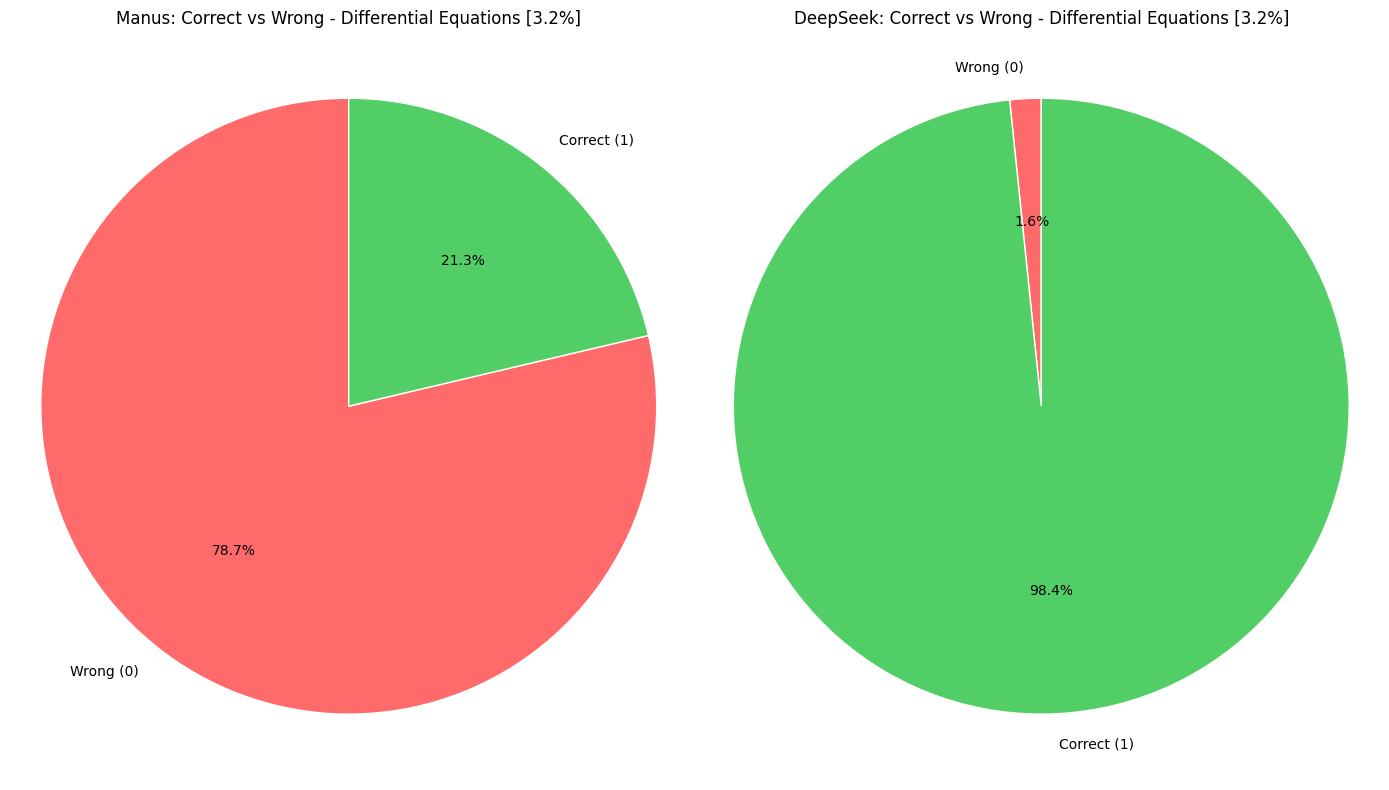

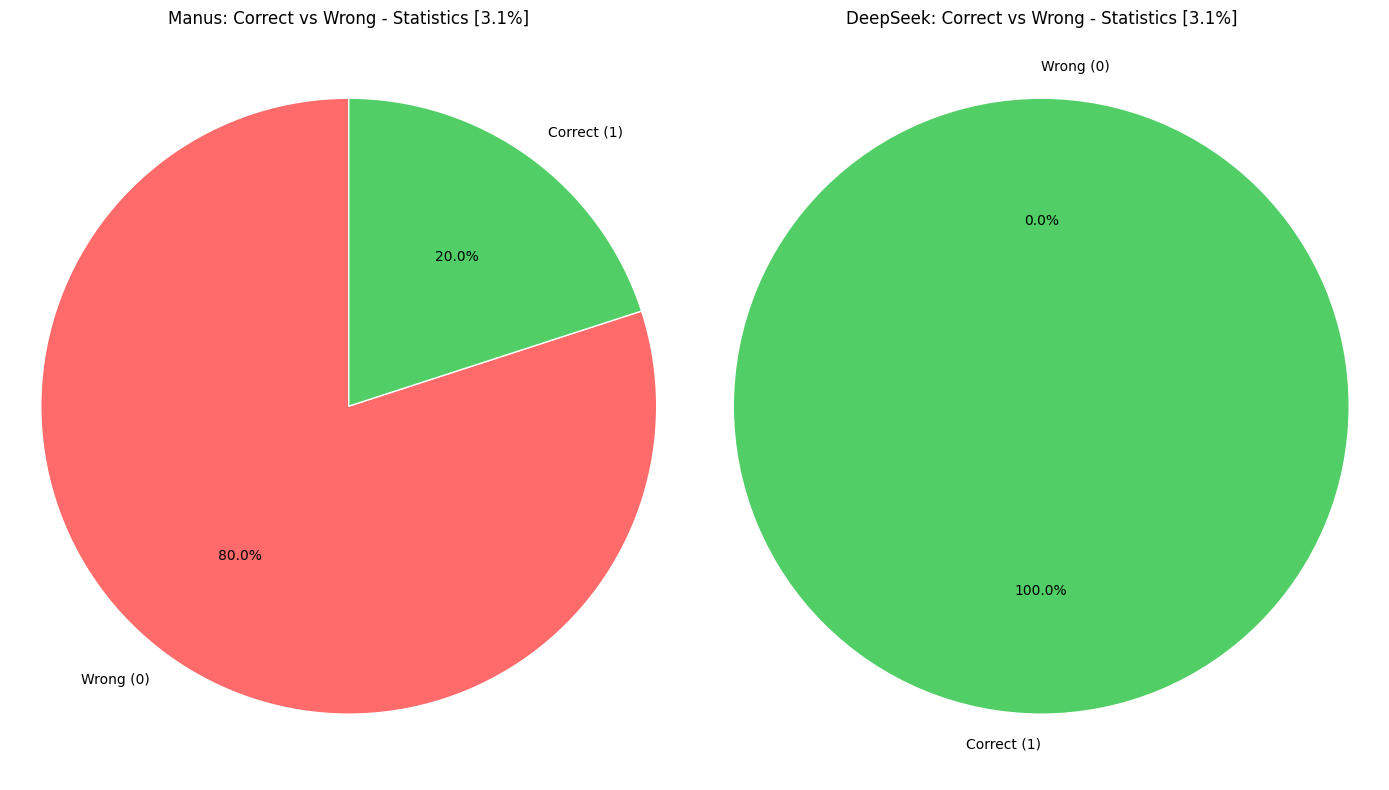

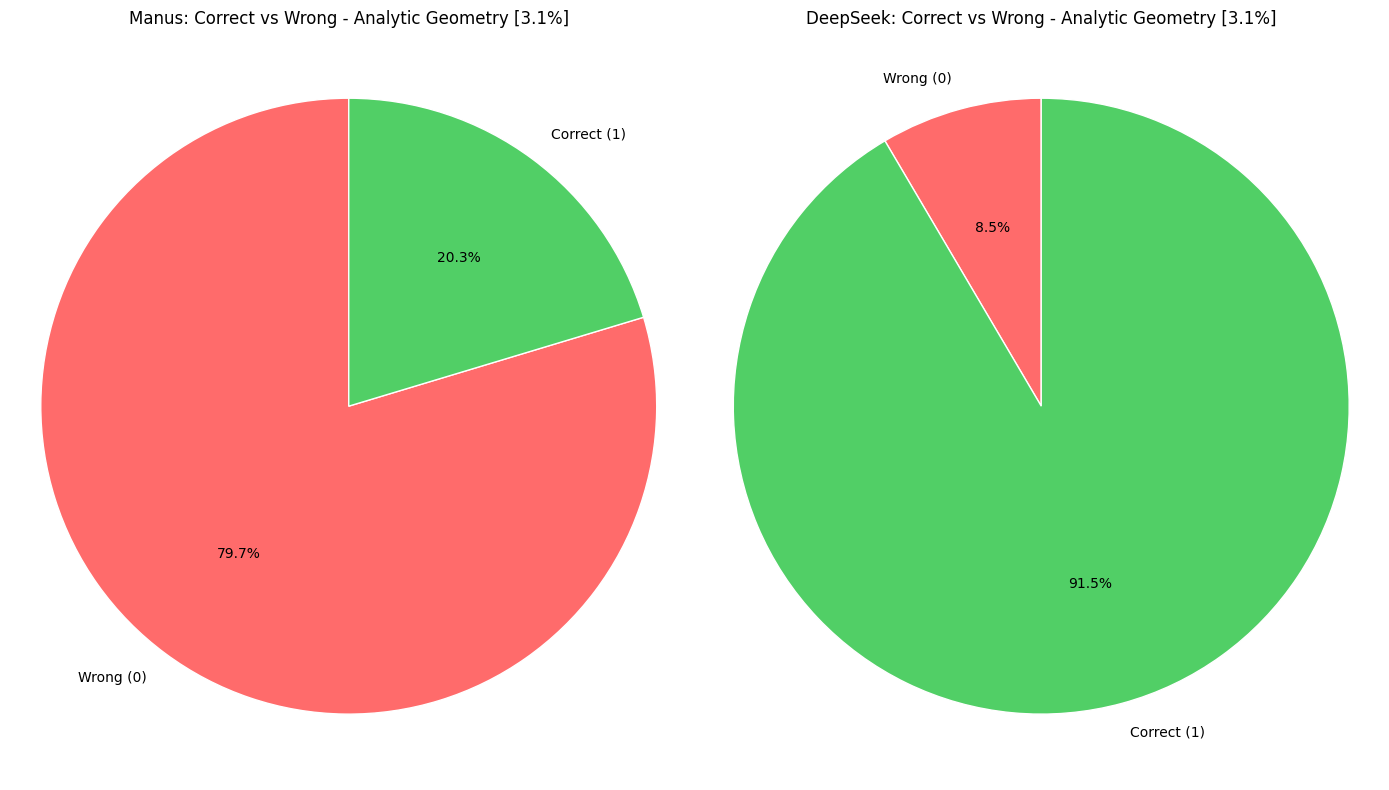

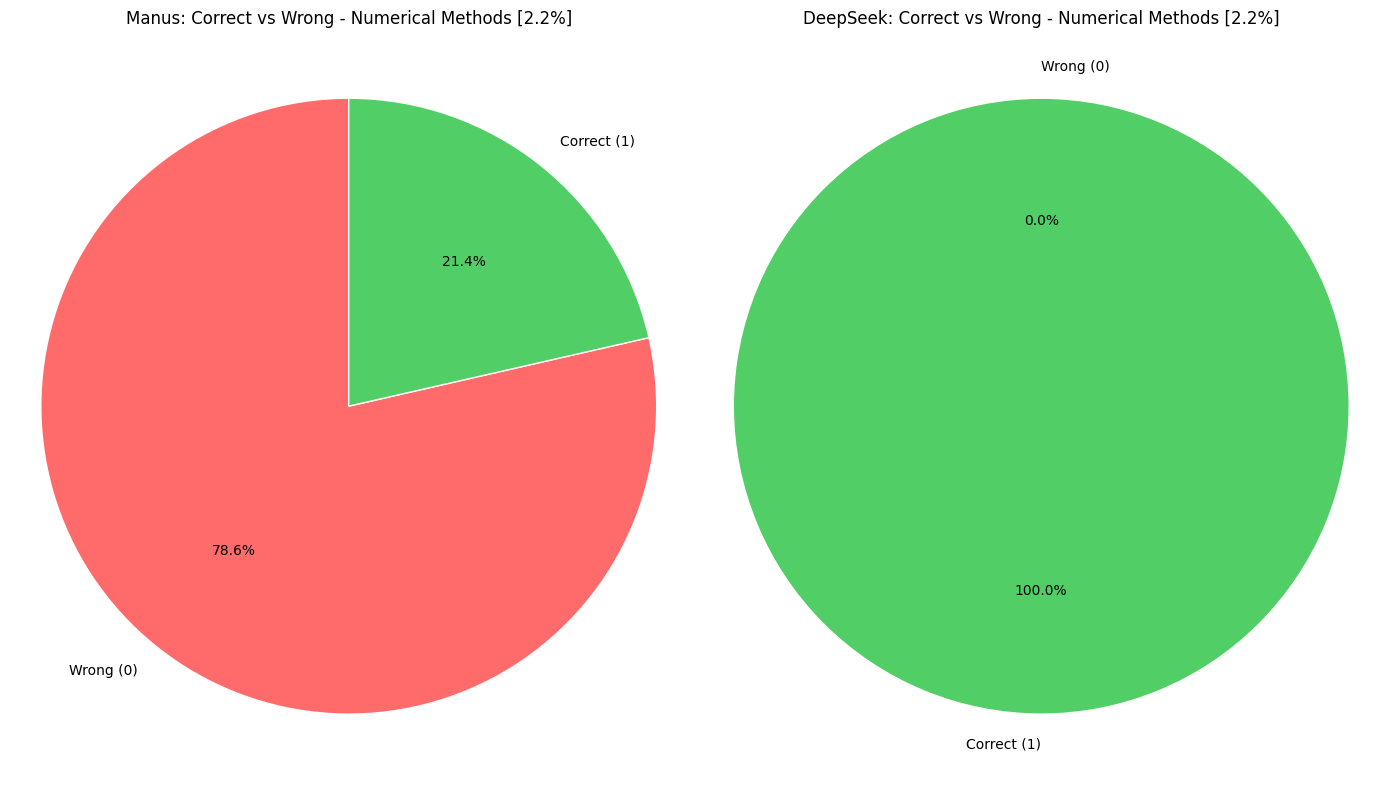

In [23]:
labels = ["Wrong (0)", "Correct (1)"]

topic_percentages = (
    mathE_LLManswer["Topic"]
    .value_counts(normalize=True)
    .mul(100)
    .sort_values(ascending=False)
 )

for element, topic_percentage in topic_percentages.items():
    subset = mathE_LLManswer[mathE_LLManswer["Topic"] == element]
    manus_counts = subset["Manus_Right"].value_counts().reindex([0, 1], fill_value=0)
    deepseek_counts = subset["DeepSeek_Right"].value_counts().reindex([0, 1], fill_value=0)

    fig, axes = plt.subplots(1, 2, figsize=(14, 8))

    for ax, counts, title in zip(
        axes,
        [manus_counts, deepseek_counts],
        [
            f"Manus: Correct vs Wrong - {element} [{topic_percentage:.1f}%]",
            f"DeepSeek: Correct vs Wrong - {element} [{topic_percentage:.1f}%]"
        ]
    ):
        if counts.sum() == 0:
            ax.text(0.5, 0.5, "No valid 0/1 values", ha="center", va="center")
            ax.set_title(title)
            ax.axis("off")
            continue

        ax.pie(
            counts.values,
            labels=labels,
            autopct="%1.1f%%",
            startangle=90,
            colors=["#ff6b6b", "#51cf66"],
            wedgeprops={"edgecolor": "white"}
        )
        ax.set_title(title)
        ax.axis("equal")

    plt.tight_layout()
    plt.show()

## MathE_public

In [24]:
mathE_public.head()

,Student ID,Student Country,Question ID,Type of Answer,Question Level,Topic,Subtopic,Keywords
0,647,Ireland,77,0,Basic,Statistics,Statistics,"Stem and Leaf diagram,Relative frequency,Sampl..."
1,41,Portugal,77,1,Basic,Statistics,Statistics,"Stem and Leaf diagram,Relative frequency,Sampl..."
2,340,Portugal,77,1,Basic,Statistics,Statistics,"Stem and Leaf diagram,Relative frequency,Sampl..."
3,641,Italy,77,0,Basic,Statistics,Statistics,"Stem and Leaf diagram,Relative frequency,Sampl..."
4,669,Portugal,77,1,Basic,Statistics,Statistics,"Stem and Leaf diagram,Relative frequency,Sampl..."


In [25]:
mathE_public.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9546 entries, 0 to 9545
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Student ID       9546 non-null   int64 
 1   Student Country  9546 non-null   object
 2   Question ID      9546 non-null   int64 
 3   Type of Answer   9546 non-null   int64 
 4   Question Level   9546 non-null   object
 5   Topic            9546 non-null   object
 6   Subtopic         9546 non-null   object
 7   Keywords         9546 non-null   object
dtypes: int64(3), object(5)
memory usage: 596.8+ KB


In [26]:
mathE_public.describe()

,Student ID,Question ID,Type of Answer
count,9546.000000,9546.000000,9546.000000
mean,775.402263,478.912319,0.468259
std,460.590559,249.244061,0.499018
min,26.000000,77.000000,0.000000
25%,380.000000,323.000000,0.000000
50%,885.000000,428.000000,0.000000
75%,1219.000000,571.000000,1.000000
max,1565.000000,1549.000000,1.000000


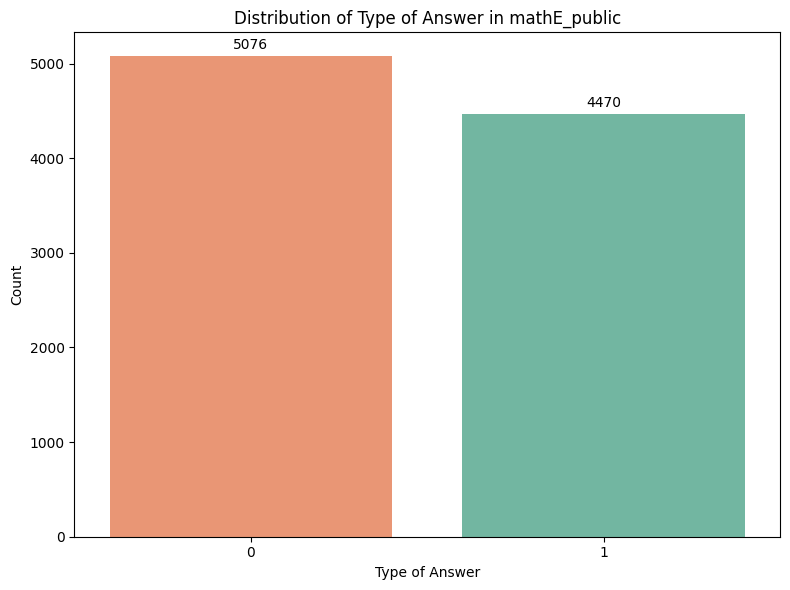

In [27]:
answer_series = mathE_public["Type of Answer"].dropna()
preferred_order = [0, 1, "0", "1"]
answer_order = [value for value in preferred_order if value in answer_series.unique().tolist()]

if not answer_order:
    answer_order = answer_series.value_counts().index.tolist()

answer_palette_map = {0: "#fc8d62", 1: "#66c2a5", "0": "#fc8d62", "1": "#66c2a5"}
answer_palette = [answer_palette_map.get(value, "#8da0cb") for value in answer_order]

plt.figure(figsize=(8, 6))
ax = sns.countplot(
    x="Type of Answer",
    data=mathE_public,
    order=answer_order,
    palette=answer_palette
 )
plt.title("Distribution of Type of Answer in mathE_public")
plt.xlabel("Type of Answer")
plt.ylabel("Count")

for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.tight_layout()
plt.show()

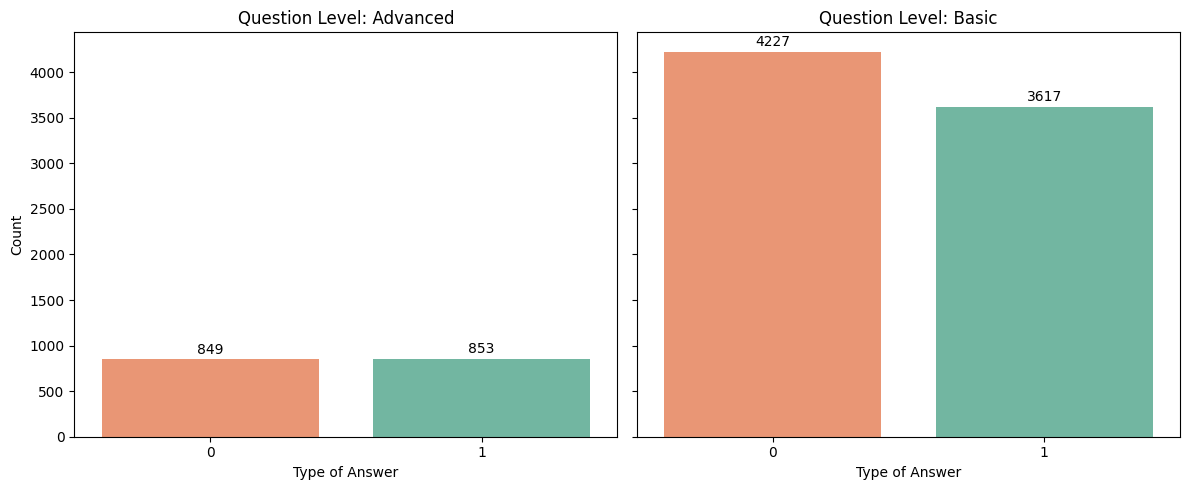

In [28]:
levels = sorted(mathE_public["Question Level"].dropna().unique())
answer_series = mathE_public["Type of Answer"].dropna()
preferred_order = [0, 1, "0", "1"]
answer_order = [value for value in preferred_order if value in answer_series.unique().tolist()]

if not answer_order:
    answer_order = answer_series.value_counts().index.tolist()

answer_palette_map = {0: "#fc8d62", 1: "#66c2a5", "0": "#fc8d62", "1": "#66c2a5"}
answer_palette = [answer_palette_map.get(value, "#8da0cb") for value in answer_order]

fig, axes = plt.subplots(1, len(levels), figsize=(6 * len(levels), 5), sharey=True)

if len(levels) == 1:
    axes = [axes]

for ax, lvl in zip(axes, levels):
    subset = mathE_public[mathE_public["Question Level"] == lvl]
    ax = sns.countplot(
        data=subset,
        x="Type of Answer",
        order=answer_order,
        palette=answer_palette,
        ax=ax
    )
    ax.set_title(f"Question Level: {lvl}")
    ax.set_xlabel("Type of Answer")
    ax.set_ylabel("Count")
    for container in ax.containers:
        ax.bar_label(container, padding=2)

plt.tight_layout()
plt.show()

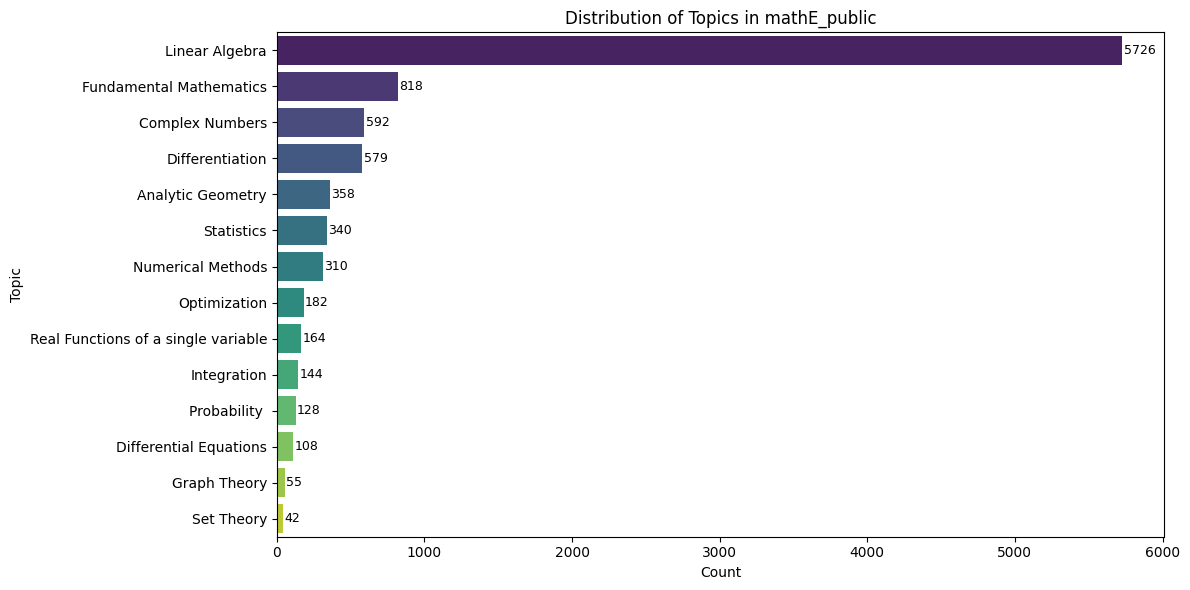

In [29]:
topic_counts_public = mathE_public["Topic"].value_counts()

plt.figure(figsize=(12, 6))
sns.barplot(
    x=topic_counts_public.values,
    y=topic_counts_public.index,
    palette="viridis"
)
plt.title("Distribution of Topics in mathE_public")
plt.xlabel("Count")
plt.ylabel("Topic")

for i, v in enumerate(topic_counts_public.values):
    plt.text(v + 10, i, str(v), va="center", fontsize=9)

plt.tight_layout()
plt.show()

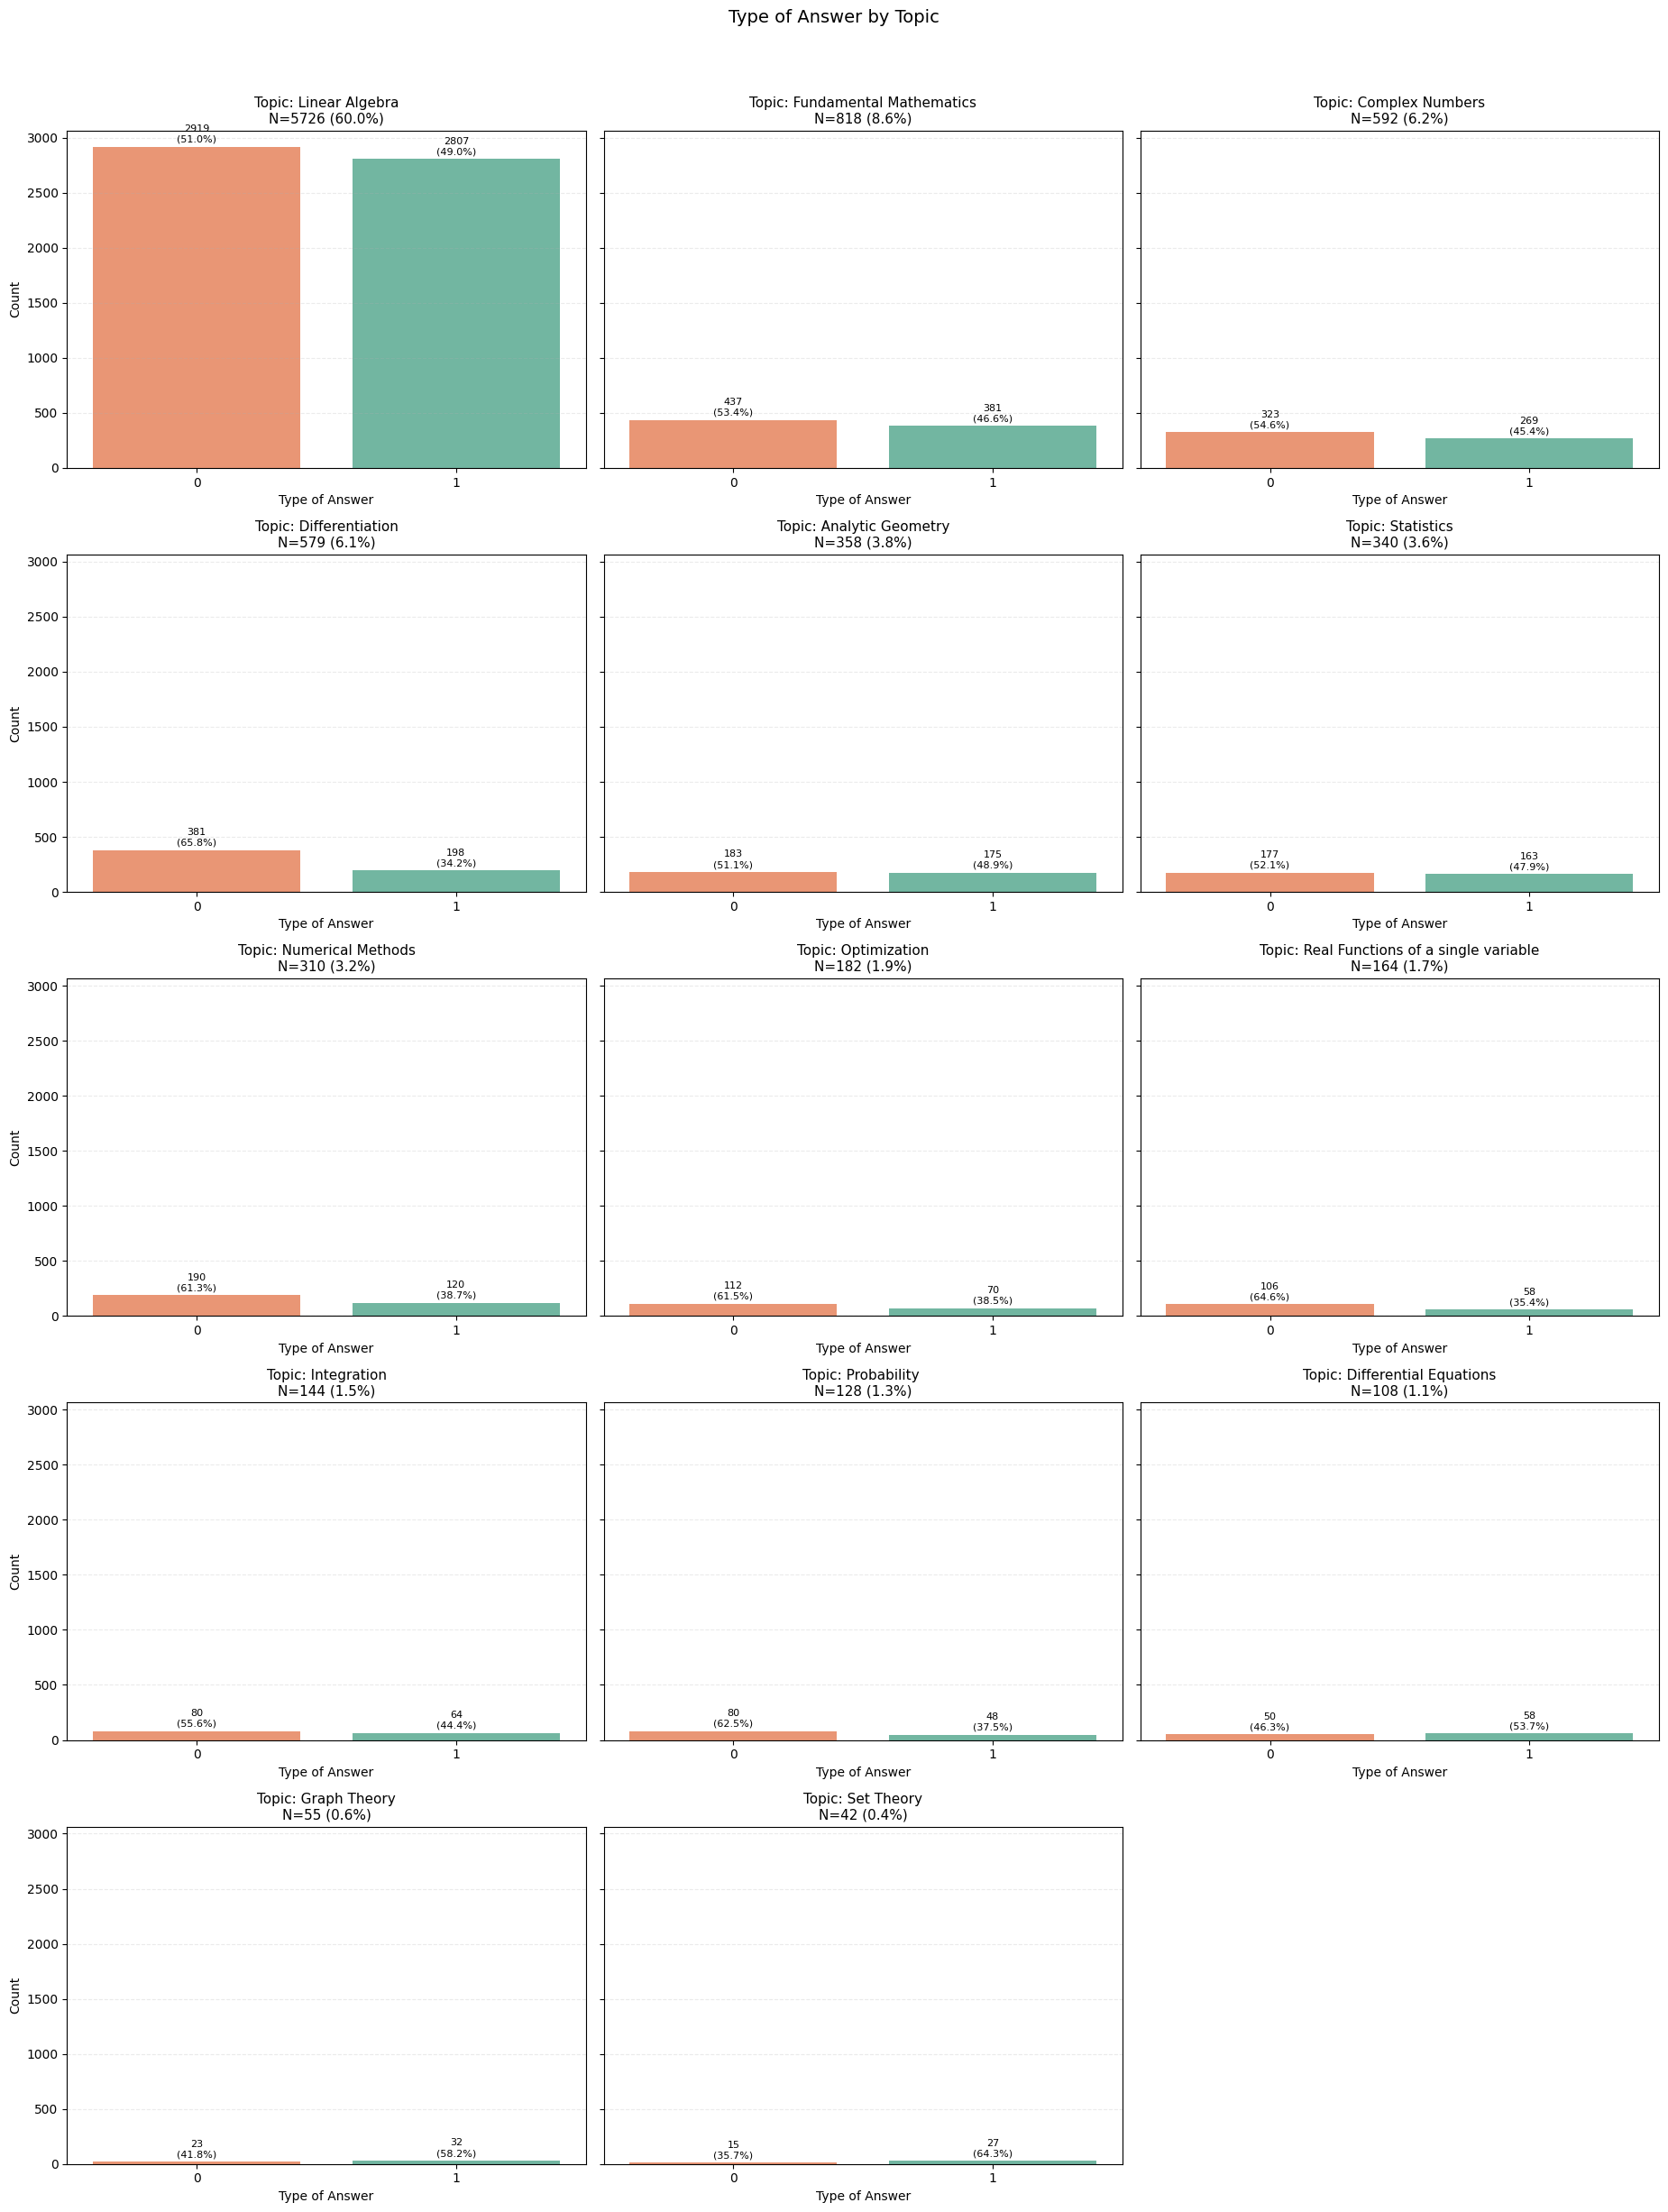

In [30]:
topic_counts = mathE_public["Topic"].dropna().value_counts()
topics = topic_counts.index.tolist()
n_topics = len(topics)

answer_series = mathE_public["Type of Answer"].dropna()
preferred_order = [0, 1, "0", "1"]
answer_order = [value for value in preferred_order if value in answer_series.unique().tolist()]

if not answer_order:
    answer_order = answer_series.value_counts().index.tolist()

answer_palette_map = {0: "#fc8d62", 1: "#66c2a5", "0": "#fc8d62", "1": "#66c2a5"}

ncols = 3
nrows = math.ceil(n_topics / ncols)

fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(6.2 * ncols, 4.8 * nrows),
    sharey=True
)

if hasattr(axes, "flatten"):
    axes = axes.flatten()
else:
    axes = [axes]

total_rows = len(mathE_public)

for ax, tps in zip(axes, topics):
    subset = mathE_public[mathE_public["Topic"] == tps]
    counts = subset["Type of Answer"].value_counts().reindex(answer_order, fill_value=0)
    bar_colors = [answer_palette_map.get(value, "#8da0cb") for value in counts.index]

    sns.barplot(
        x=counts.index,
        y=counts.values,
        palette=bar_colors,
        ax=ax
    )

    topic_pct = (len(subset) / total_rows * 100) if total_rows else 0
    ax.set_title(f"Topic: {tps}\nN={len(subset)} ({topic_pct:.1f}%)", fontsize=11)
    ax.set_xlabel("Type of Answer")
    ax.set_ylabel("Count")
    ax.grid(axis="y", linestyle="--", alpha=0.25)

    for container in ax.containers:
        labels = []
        for bar in container:
            height = bar.get_height()
            pct = (height / len(subset) * 100) if len(subset) else 0
            labels.append(f"{int(height)}\n({pct:.1f}%)")
        ax.bar_label(container, labels=labels, padding=2, fontsize=8)

for ax in axes[n_topics:]:
    ax.set_visible(False)

fig.suptitle("Type of Answer by Topic", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [31]:
# Split the "Keywords" column into a list of keywords
mathE_public["Keywords"] = (
    mathE_public["Keywords"]
    .str.split(",")
    .apply(lambda x: [k.strip() for k in x] if isinstance(x, list) else x)
)

# Optional: one keyword per row
mathE_public_sk = mathE_public.explode("Keywords")

mathE_public_sk.head()

,Student ID,Student Country,Question ID,Type of Answer,Question Level,Topic,Subtopic,Keywords
0,647,Ireland,77,0,Basic,Statistics,Statistics,Stem and Leaf diagram
0,647,Ireland,77,0,Basic,Statistics,Statistics,Relative frequency
0,647,Ireland,77,0,Basic,Statistics,Statistics,Sample
0,647,Ireland,77,0,Basic,Statistics,Statistics,Frequency
1,41,Portugal,77,1,Basic,Statistics,Statistics,Stem and Leaf diagram


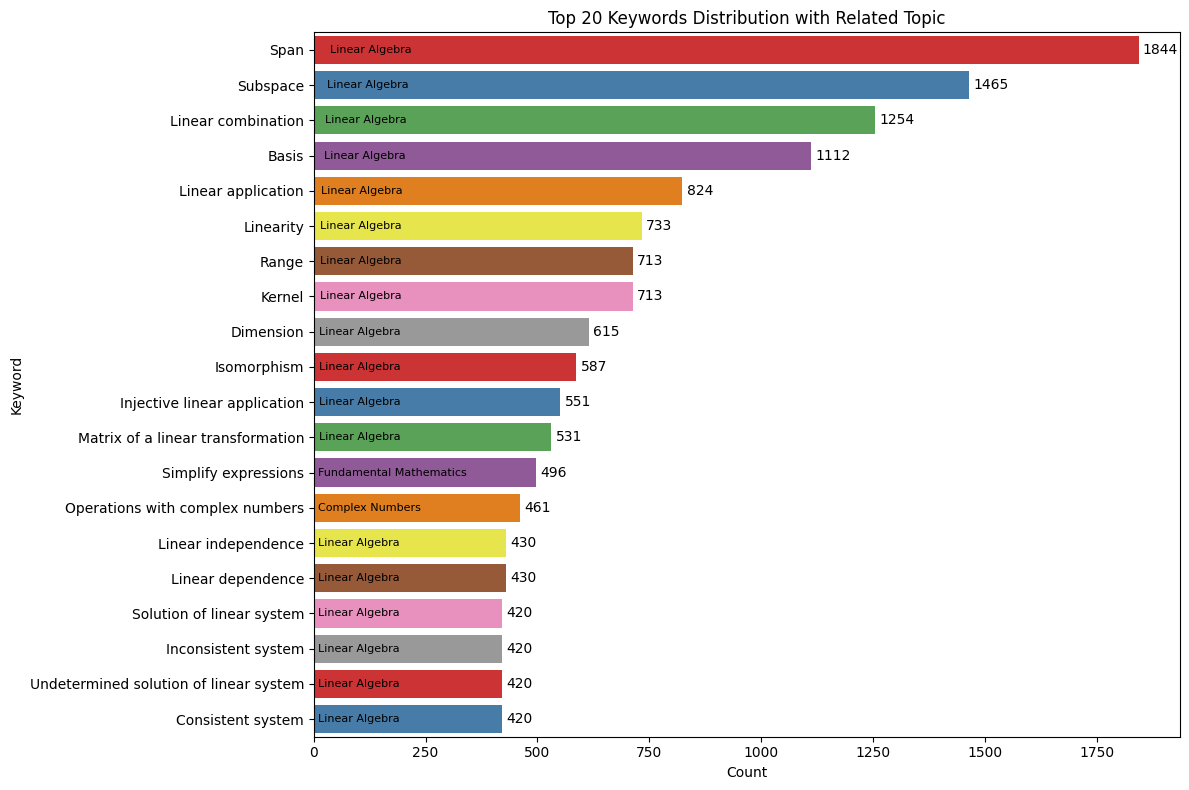

In [32]:

top_keywords = (
    mathE_public_sk["Keywords"]
    .dropna()
    .value_counts()
    .head(20)
    .rename_axis("Keywords")
    .reset_index(name="Count")
)

keyword_topics = (
    mathE_public_sk.dropna(subset=["Keywords", "Topic"])

    .groupby("Keywords")["Topic"]
    .agg(lambda values: values.mode().iloc[0] if not values.mode().empty else "N/A")
    .reset_index()
)

top_keywords = top_keywords.merge(keyword_topics, on="Keywords", how="left")
top_keywords["Topic"] = top_keywords["Topic"].fillna("N/A")

fig, ax = plt.subplots(figsize=(12, 8))
sns.barplot(
    data=top_keywords,
    x="Count",
    y="Keywords",
    palette="Set1",
    ax=ax
)

ax.set_title("Top 20 Keywords Distribution with Related Topic")
ax.set_xlabel("Count")
ax.set_ylabel("Keyword")

for i, (i, row) in enumerate(top_keywords.iterrows()):
    ax.text(
        max(row["Count"] * 0.02, 0.3),
        i,
        str(row["Topic"]),
        va="center",
        ha="left",
        color="black",
        fontsize=8,
        #fontweight="bold"
    )

for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.tight_layout()
plt.show()

## questions_information

In [33]:
questions_information.head()

,id,question,algorithmLevel,validate,Validator,Topic,Correct,Incorrect1,Incorrect2,Incorrect3,LecturerLevel,Subtopic,countMaterials,countVideos,Author
0,79,What number is missing from the table?\n\n$\be...,3,1,Ana I.,Statistics,$180$,$150$,$1020$,$400$,1,NaN,4,2,Lina
1,80,The amount spent on entertainment in a month w...,3,1,Ana I.,Statistics,$167 €$,$200 €$,$120 €$,$325 €$,1,NaN,3,6,Lina
2,81,The amount spent on entertainment in a month w...,3,1,Ana I.,Statistics,$120 €$,$200 €$,$167 €$,$325 €$,1,NaN,3,5,Lina
3,82,Differentiate $\displaystyle{y = 2x\sin(x)}$.,1,1,Ana I.,Differentiation,$2\left(\sin\left(x\right)+x\cos\left(x\right)...,$\left(\sin\left(2x\right)+x\cos\left(2x\right...,$2x\left(\sin\left(x\right)+x\cos\left(x\right...,$\left(2\sin\left(x\right)-2x\cos\left(x\right...,1,Derivatives,9,19,Rita
4,83,The image of the function $f(x)=x^3+\log (x)$ is,1,1,Maria de Fátima,Real Functions of a Single Variable,$\mathbb{R}$,"$(0,+\infty)$","$[0,+\infty)$","$(-\infty,0)$",2,"Domain, Image and Graphics",1,8,Giovanni S.


In [34]:
questions_information.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1913 entries, 0 to 1912
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   id              1913 non-null   int64 
 1   question        1913 non-null   object
 2   algorithmLevel  1913 non-null   int64 
 3   validate        1913 non-null   int64 
 4   Validator       1910 non-null   object
 5   Topic           1913 non-null   object
 6   Correct         1913 non-null   object
 7   Incorrect1      1913 non-null   object
 8   Incorrect2      1913 non-null   object
 9   Incorrect3      1913 non-null   object
 10  LecturerLevel   1913 non-null   int64 
 11  Subtopic        1447 non-null   object
 12  countMaterials  1913 non-null   int64 
 13  countVideos     1913 non-null   int64 
 14  Author          1913 non-null   object
dtypes: int64(6), object(9)
memory usage: 224.3+ KB


In [35]:
questions_information.describe()

,id,algorithmLevel,validate,LecturerLevel,countMaterials,countVideos
count,1913.000000,1913.000000,1913.000000,1913.000000,1913.000000,1913.000000
mean,1127.670152,2.682175,1.020387,2.940408,10.067433,8.092002
std,619.963420,1.358524,0.141356,1.341564,15.206980,5.430322
min,79.000000,1.000000,1.000000,0.000000,0.000000,0.000000
25%,580.000000,2.000000,1.000000,2.000000,2.000000,4.000000
50%,1099.000000,3.000000,1.000000,3.000000,4.000000,7.000000
75%,1679.000000,4.000000,1.000000,4.000000,9.000000,11.000000
max,2187.000000,6.000000,2.000000,5.000000,72.000000,30.000000


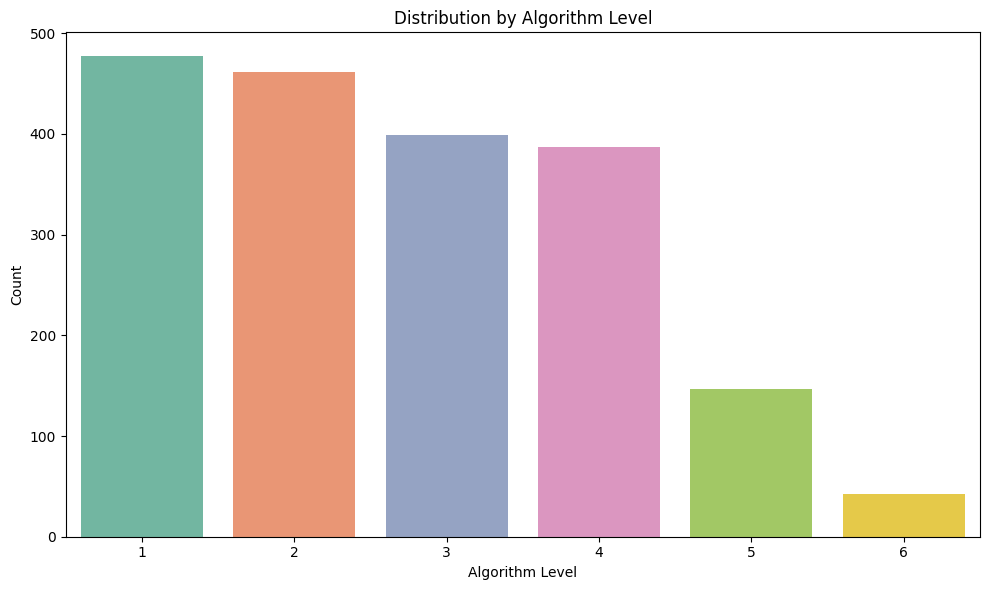

In [36]:
plt.figure(figsize=(10, 6))
sns.countplot(x="algorithmLevel", data=questions_information, palette="Set2")
plt.title("Distribution by Algorithm Level")
plt.xlabel("Algorithm Level")
plt.ylabel("Count")

plt.tight_layout()
plt.show()


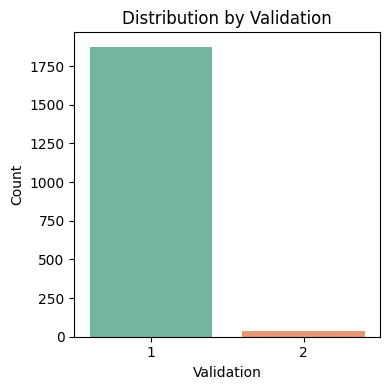

In [37]:
plt.figure(figsize=(4, 4))
sns.countplot(x="validate", data=questions_information, palette="Set2")
plt.title("Distribution by Validation")
plt.xlabel("Validation")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

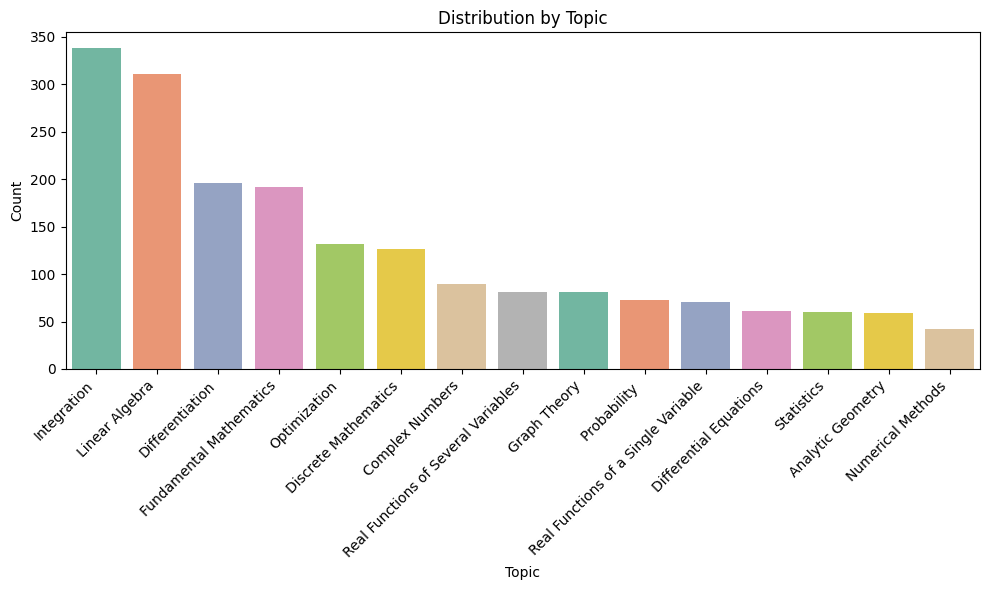

In [38]:
plt.figure(figsize=(10, 6))
topic_order = questions_information["Topic"].value_counts().index
sns.countplot(x="Topic", data=questions_information, order=topic_order, palette="Set2")
plt.title("Distribution by Topic")
plt.xticks(rotation=45, ha="right")
plt.xlabel("Topic")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

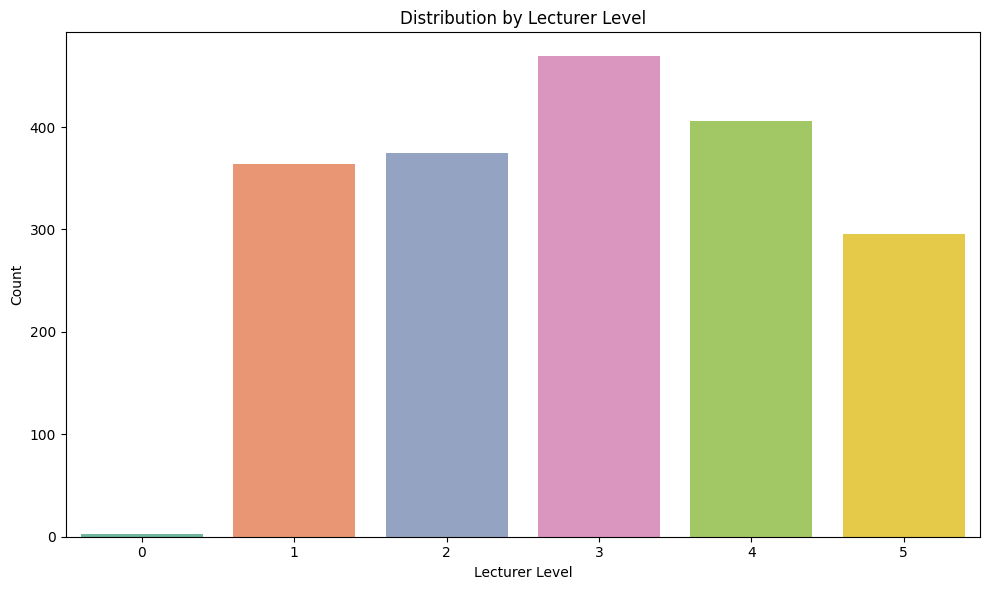

In [39]:
plt.figure(figsize=(10, 6))
sns.countplot(x="LecturerLevel", data=questions_information, palette="Set2")
plt.title("Distribution by Lecturer Level")
plt.xlabel("Lecturer Level")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

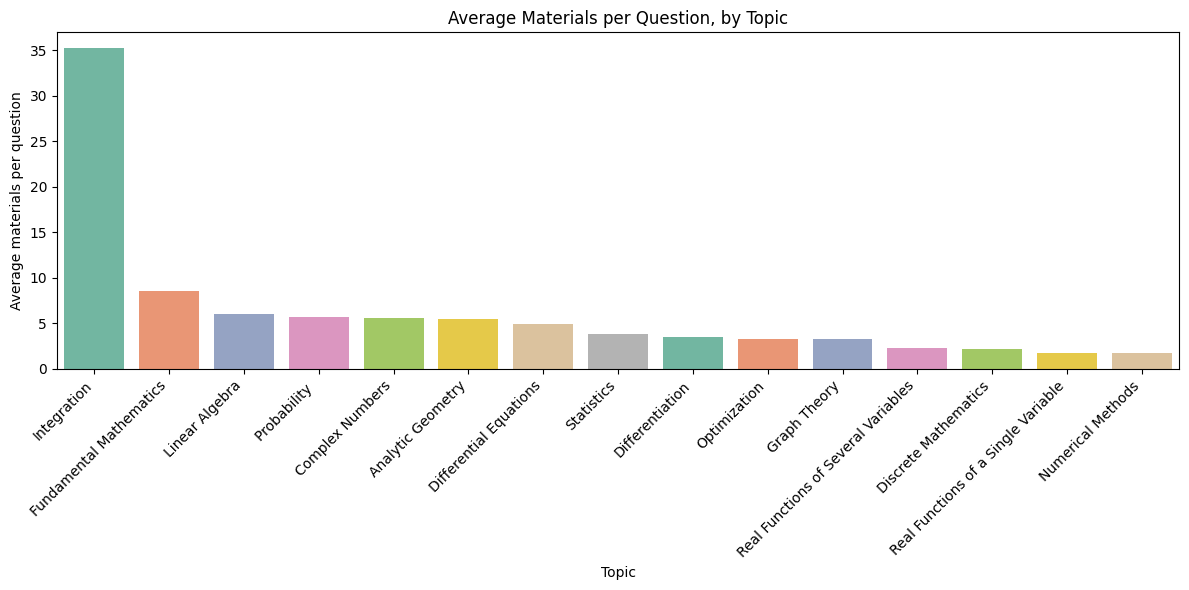

In [40]:
plt.figure(figsize=(12, 6))
materials_by_topic = (
    questions_information.groupby("Topic", dropna=False)
    .agg(
        total_materials=("countMaterials", "sum"),
        question_count=("Topic", "size")
    )
    .reset_index()
)
materials_by_topic["materials_per_question"] = (
    materials_by_topic["total_materials"] / materials_by_topic["question_count"]
)
materials_by_topic = materials_by_topic.sort_values("materials_per_question", ascending=False)

sns.barplot(
    data=materials_by_topic,
    x="Topic",
    y="materials_per_question",
    palette="Set2"
 )
plt.title("Average Materials per Question, by Topic")
plt.xticks(rotation=45, ha="right")
plt.xlabel("Topic")
plt.ylabel("Average materials per question")

plt.tight_layout()
plt.show()

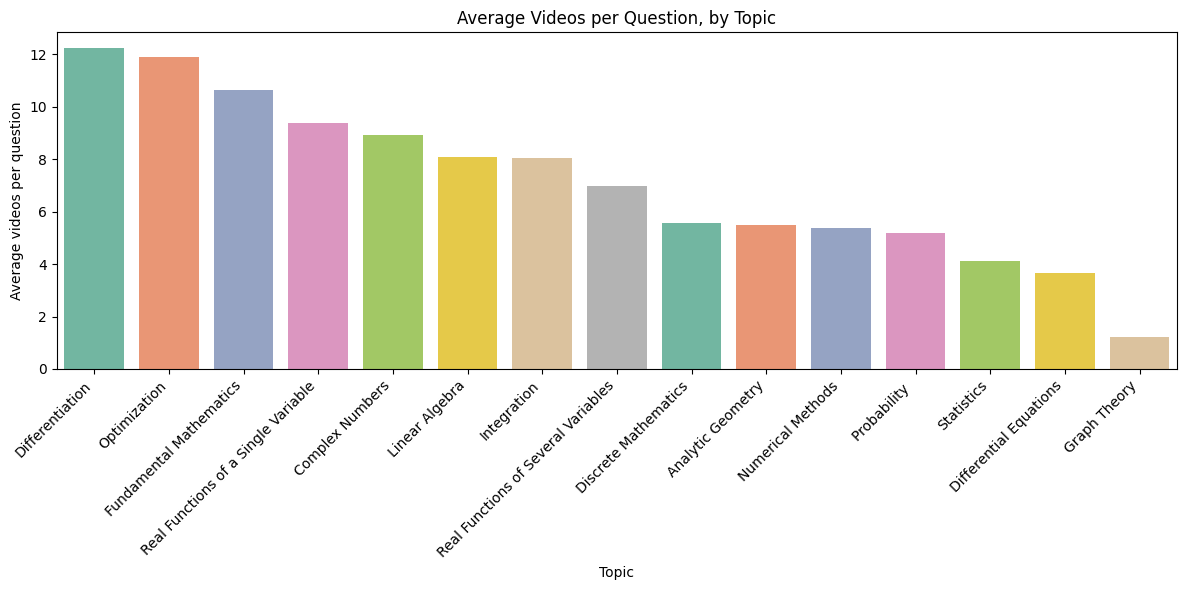

In [41]:
plt.figure(figsize=(12, 6))
videos_by_topic = (
    questions_information.groupby("Topic", dropna=False)
    .agg(
        total_videos=("countVideos", "sum"),
        question_count=("Topic", "size")
    )
    .reset_index()
)
videos_by_topic["videos_per_question"] = (
    videos_by_topic["total_videos"] / videos_by_topic["question_count"]
)
videos_by_topic = videos_by_topic.sort_values("videos_per_question", ascending=False)

sns.barplot(
    data=videos_by_topic,
    x="Topic",
    y="videos_per_question",
    palette="Set2"
 )
plt.title("Average Videos per Question, by Topic")
plt.xticks(rotation=45, ha="right")
plt.xlabel("Topic")
plt.ylabel("Average videos per question")

plt.tight_layout()
plt.show()

## teaching_material_information

In [42]:
teaching_material_information.head()

,id,clicks,Topic,Subtopic
0,9,0,Real Functions of a Single Variable,Limits and Continuity
1,10,1,Real Functions of a Single Variable,Limits and Continuity
2,11,0,Real Functions of a Single Variable,Limits and Continuity
3,12,0,Real Functions of a Single Variable,"Domain, Image and Graphics"
4,13,0,Real Functions of a Single Variable,"Domain, Image and Graphics"


In [43]:
teaching_material_information.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 447 entries, 0 to 446
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        447 non-null    int64 
 1   clicks    447 non-null    int64 
 2   Topic     447 non-null    object
 3   Subtopic  365 non-null    object
dtypes: int64(2), object(2)
memory usage: 14.1+ KB


In [44]:
teaching_material_information.describe()

,id,clicks
count,447.000000,447.000000
mean,324.986577,0.201342
std,247.000953,0.769193
min,1.000000,0.000000
25%,147.500000,0.000000
50%,285.000000,0.000000
75%,419.500000,0.000000
max,965.000000,13.000000


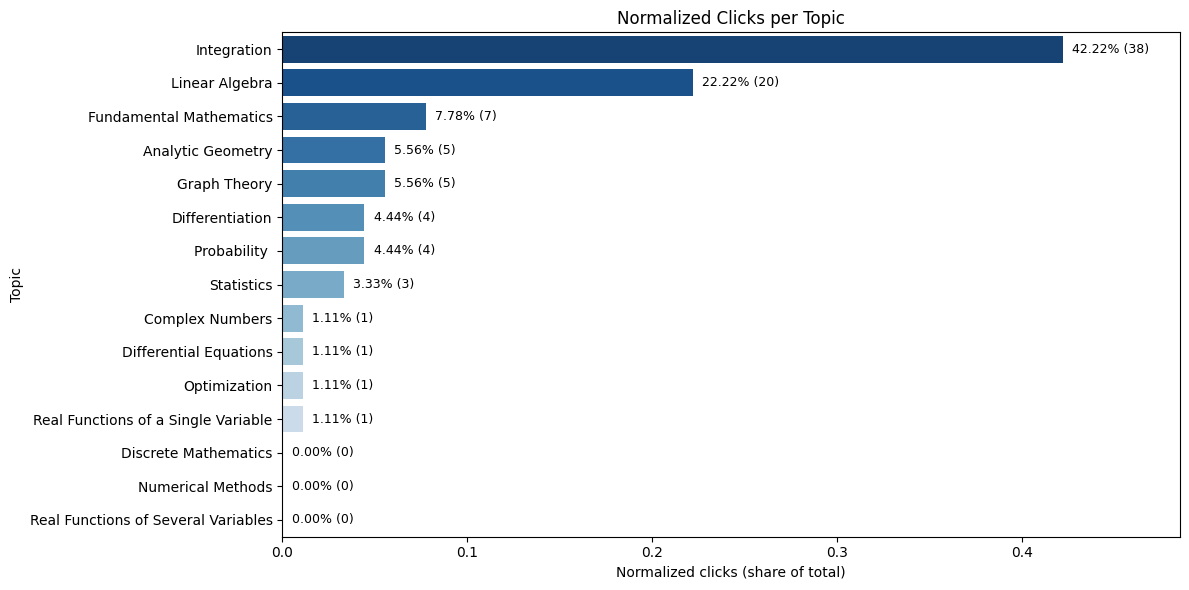

In [45]:
# Clicks per topic normalized by total clicks
clicks_by_topic = (
    teaching_material_information.groupby("Topic", dropna=False)["clicks"]
    .sum()
    .sort_values(ascending=False)
)

total_clicks = clicks_by_topic.sum()
clicks_by_topic_norm = clicks_by_topic / total_clicks if total_clicks > 0 else clicks_by_topic * 0

plt.figure(figsize=(12, 6))
ax = sns.barplot(
    x=clicks_by_topic_norm.values,
    y=clicks_by_topic_norm.index,
    palette="Blues_r"
)
plt.title("Normalized Clicks per Topic")
plt.xlabel("Normalized clicks (share of total)")
plt.ylabel("Topic")

for i, (pct, count) in enumerate(zip(clicks_by_topic_norm.values, clicks_by_topic.values)):
    ax.text(pct + 0.005, i, f"{pct:.2%} ({int(count):,})", va="center", fontsize=9)

plt.xlim(0, max(clicks_by_topic_norm.values) * 1.15 if len(clicks_by_topic_norm) else 1)
plt.tight_layout()
plt.show()

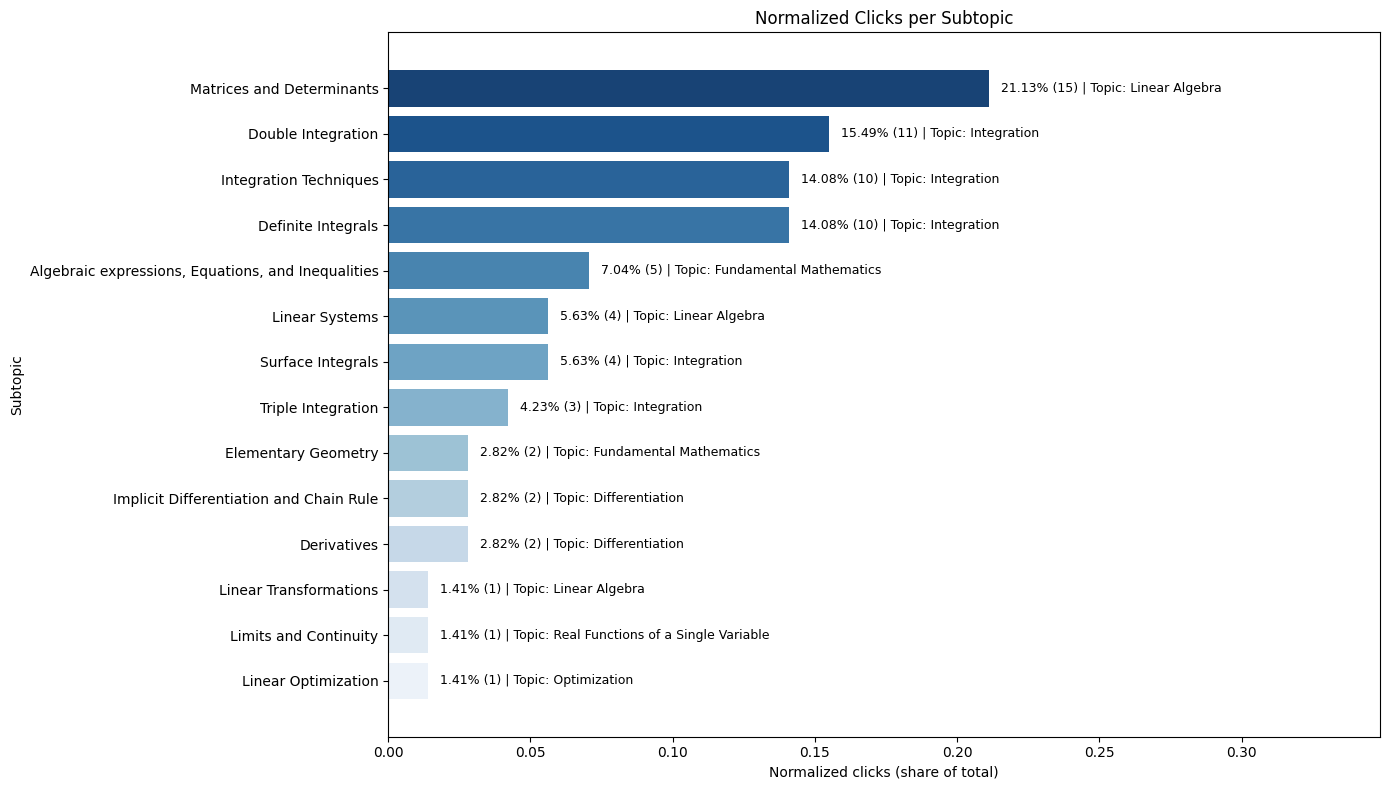

In [46]:
# Clicks per subtopic normalized by total clicks, with related topic labels
clicks_by_subtopic = (
    teaching_material_information.groupby("Subtopic", dropna=False)["clicks"]
    .sum()
    .sort_values(ascending=False)
)

# Exclude missing subtopics and keep only subtopics with at least one click
clicks_by_subtopic = clicks_by_subtopic[clicks_by_subtopic.index.notna()]
clicks_by_subtopic = clicks_by_subtopic[clicks_by_subtopic > 0]

# Map each subtopic to its most frequent related topic
subtopic_topic_map = (
    teaching_material_information.dropna(subset=["Subtopic"])
    .groupby("Subtopic")["Topic"]
    .agg(lambda s: s.mode().iloc[0] if not s.mode().empty else "N/A")
)

total_clicks_subtopic = clicks_by_subtopic.sum()
clicks_by_subtopic_norm = (
    clicks_by_subtopic / total_clicks_subtopic
    if total_clicks_subtopic > 0
    else clicks_by_subtopic * 0
)

subtopic_topics = [
    str(subtopic_topic_map.get(subtopic, "N/A"))
    for subtopic in clicks_by_subtopic.index
]

plt.figure(figsize=(14, 8))
ax = sns.barplot(
    x=clicks_by_subtopic_norm.values,
    y=clicks_by_subtopic.index,
    palette="Blues_r"
 )
plt.title("Normalized Clicks per Subtopic")
plt.xlabel("Normalized clicks (share of total)")
plt.ylabel("Subtopic")
ax.margins(y=0.06)

x_max = max(clicks_by_subtopic_norm.values) if len(clicks_by_subtopic_norm) else 1
for i, (pct, count, topic) in enumerate(zip(clicks_by_subtopic_norm.values, clicks_by_subtopic.values, subtopic_topics)):
    ax.text(
        pct + x_max * 0.02,
        i,
        f"{pct:.2%} ({int(count):,}) | Topic: {topic}",
        va="center",
        fontsize=9,
    )

plt.xlim(0, x_max * 1.65 if len(clicks_by_subtopic_norm) else 1)
plt.tight_layout()
plt.show()

## pdf_keywords

In [47]:
pdf_keywords.head()

,material_id,keywords
0,9,"Continuity, Discontinuity"
1,20,Polar coordinates
2,21,Product rule
3,22,Product rule
4,24,"Product rule, Trigonometric rules"


In [48]:
# Split the "Keywords" column into a list of keywords
pdf_keywords["keywords"] = (
    pdf_keywords["keywords"]
    .str.split(",")
    .apply(lambda x: [k.strip() for k in x] if isinstance(x, list) else x)
)

# Optional: one keyword per row
pdf_keywords_sk = pdf_keywords.explode("keywords")

pdf_keywords_sk.head()

,material_id,keywords
0,9,Continuity
0,9,Discontinuity
1,20,Polar coordinates
2,21,Product rule
3,22,Product rule


In [49]:
pdf_keywords_sk.info()

<class 'pandas.core.frame.DataFrame'>
Index: 985 entries, 0 to 429
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   material_id  985 non-null    int64 
 1   keywords     985 non-null    object
dtypes: int64(1), object(1)
memory usage: 23.1+ KB


In [50]:
pdf_keywords_sk.describe()

,material_id
count,985.000000
mean,339.249746
std,259.684566
min,9.000000
25%,157.000000
50%,282.000000
75%,409.000000
max,965.000000


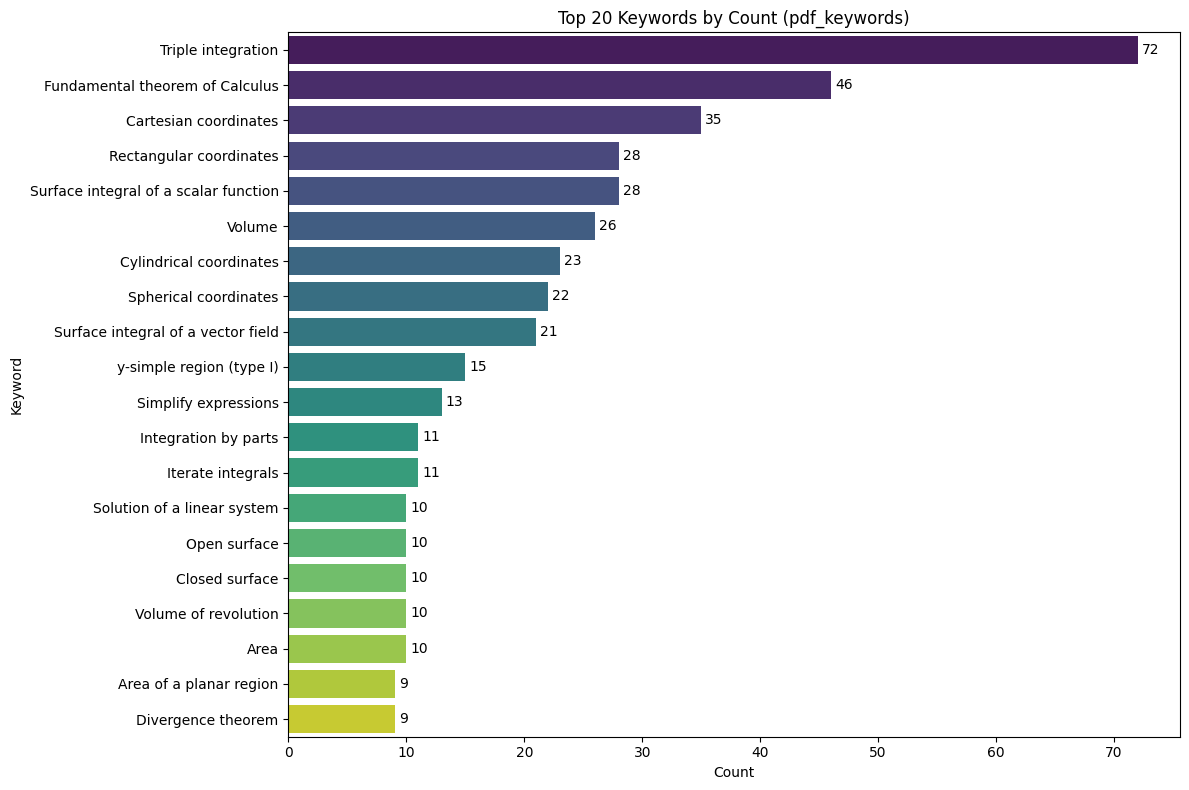

In [51]:
keyword_counts = (
    pdf_keywords_sk["keywords"]
    .dropna()
    .value_counts()
    .reset_index()
)
keyword_counts.columns = ["keyword", "count"]

plt.figure(figsize=(12, 8))
ax = sns.barplot(
    data=keyword_counts.head(20),
    x="count",
    y="keyword",
    palette="viridis"
)

plt.title("Top 20 Keywords by Count (pdf_keywords)")
plt.xlabel("Count")
plt.ylabel("Keyword")

for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.tight_layout()
plt.show()

## platform_materials-1

In [52]:
platform_materials.head()

,material_id,keywords
0,NaN,NaN
1,39.0,"Simplify expressions, Square roots"
2,NaN,NaN
3,52.0,"Properties of the determinant, Commuting matr..."
4,NaN,NaN


In [53]:
print('Original shape:', platform_materials.shape)
platform_materials.dropna(subset=["material_id"], inplace=True)
print('\nShape after dropping NA values:', platform_materials.shape)

Original shape: (178, 2)

Shape after dropping NA values: (89, 2)


In [54]:
# Split the "Keywords" column into a list of keywords
platform_materials["keywords"] = (
    platform_materials["keywords"]
    .str.split(",")
    .apply(lambda x: [k.strip() for k in x] if isinstance(x, list) else x)
)

# Optional: one keyword per row
platform_materials_sk = platform_materials.explode("keywords")

platform_materials_sk.head()

,material_id,keywords
1,39.0,Simplify expressions
1,39.0,Square roots
3,52.0,Properties of the determinant
3,52.0,Commuting matrices
3,52.0,Determinant computation


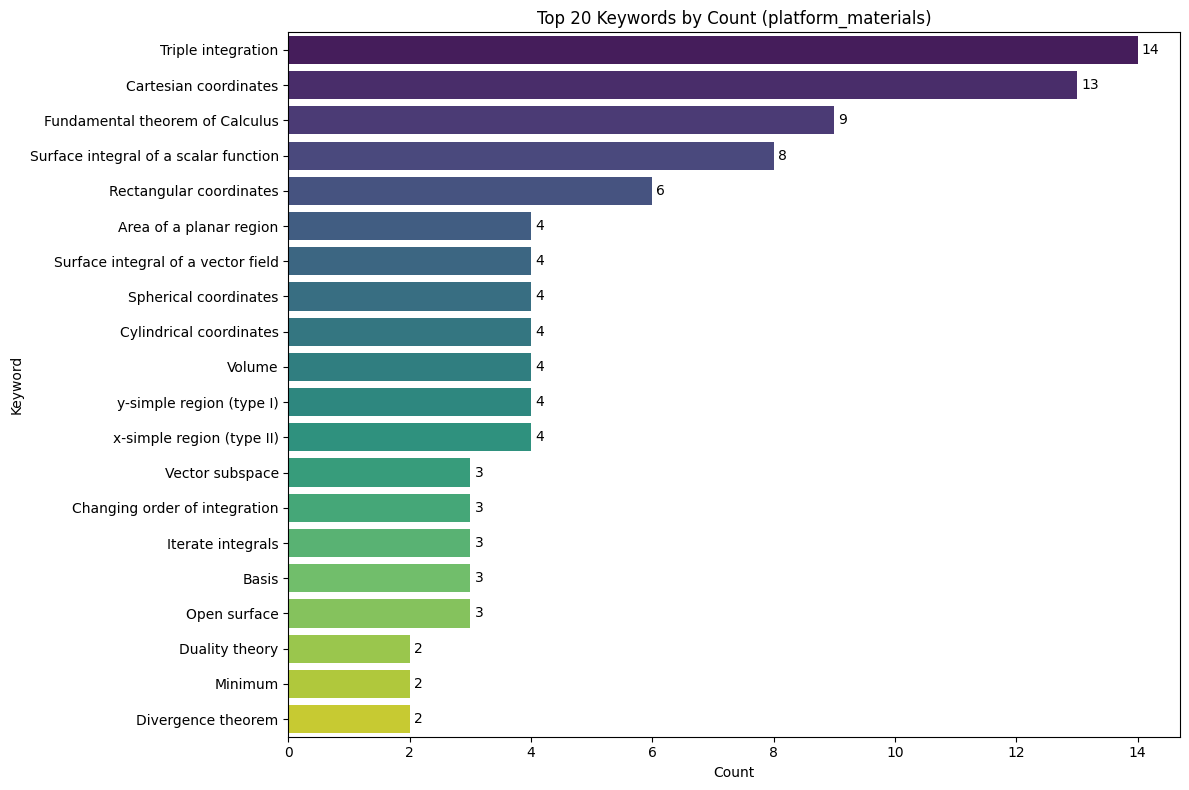

In [55]:
keyword_counts = (
    platform_materials_sk["keywords"]
    .dropna()
    .value_counts()
    .reset_index()
)
keyword_counts.columns = ["keyword", "count"]

plt.figure(figsize=(12, 8))
ax = sns.barplot(
    data=keyword_counts.head(20),
    x="count",
    y="keyword",
    palette="viridis"
)

plt.title("Top 20 Keywords by Count (platform_materials)")
plt.xlabel("Count")
plt.ylabel("Keyword")

for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.tight_layout()
plt.show()

## DataGEMS & MathE Example of questions and answers

In [56]:
datagems_example_q_a.head()

,Indicate your academic position:,What questions would you like to ask the DataGEMS Chat about general topics or the data you have uploaded (if applicable)?,What answer do you expect from this Chat? What topics should this answer address?
0,Teacher,What are the basic concepts of learning linear...,Start by solving linear equations and inequali...
1,Teacher,How do I begin my study about linear optimizat...,A good starting point is solving a problem gra...
2,Teacher,What kind of materials can I find on the mathE...,"You can find written and videos, which you can..."
3,Teacher,How do I find suitable study materials?,"In the library, select the topic you are study..."
4,Teacher,How do I begin my study?,"Firstly, you should read the theoretical conce..."


In [57]:
datagems_example_q_a.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34 entries, 0 to 33
Data columns (total 3 columns):
 #   Column                                                                                                                      Non-Null Count  Dtype 
---  ------                                                                                                                      --------------  ----- 
 0   Indicate your academic position:                                                                                            34 non-null     object
 1   What questions would you like to ask the DataGEMS Chat about general topics or the data you have uploaded (if applicable)?  34 non-null     object
 2   What answer do you expect from this Chat? What topics should this answer address?                                           34 non-null     object
dtypes: object(3)
memory usage: 948.0+ bytes


In [58]:
datagems_example_q_a.describe()

,Indicate your academic position:,What questions would you like to ask the DataGEMS Chat about general topics or the data you have uploaded (if applicable)?,What answer do you expect from this Chat? What topics should this answer address?
count,34,34,34
unique,2,34,34
top,Teacher,What are the basic concepts of learning linear...,Start by solving linear equations and inequali...
freq,26,1,1


## DataGEMS Chat examples

In [59]:
datagems_chat_example.head()

,Unnamed: 0,Unnamed: 1,Unnamed: 2
0,Researcher,What types of variables are in this dataset?,The dataset under analysis contains variables ...
1,Researcher,"Based on the uploaded data, what are the gaps ...",The answer should address possible limitations...
2,Student,What are the datasets regarding some type of b...,I expect highly trustworthy answers based on w...
3,Student,What are their access policy (freely available?)?,I expect highly trustworthy answers based on w...
4,Student,Could you summarize their characteristics in t...,I expect highly trustworthy answers based on w...


In [60]:
datagems_chat_example.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  32 non-null     object
 1   Unnamed: 1  32 non-null     object
 2   Unnamed: 2  32 non-null     object
dtypes: object(3)
memory usage: 900.0+ bytes


In [61]:
datagems_chat_example.describe()

,Unnamed: 0,Unnamed: 1,Unnamed: 2
count,32,32,32
unique,3,32,21
top,Researcher,What types of variables are in this dataset?,I expect highly trustworthy answers based on w...
freq,16,1,6
